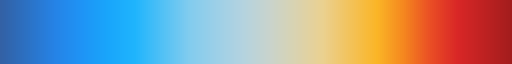

In [2]:
%load_ext autoreload
%autoreload 2
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron")
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import sparse
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# 渐变 colormap
exp_colors = ["#EDEDED", "#FFF7F3","#F7FCF0","#E0F3DB","#CCEBC5","#7BCCC4","#4EB3D3","#2B8CBE","#0868AC","#084081"]
exp_cmap = LinearSegmentedColormap.from_list("my_cmap", exp_colors, N=256)
exp_cmap

acc_colors = ["#EDEDED", "#fddfdb","#edb8b0","#e69191","#c25759"]
acc_cmap = LinearSegmentedColormap.from_list("my_cmap", acc_colors, N=256)
acc_cmap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

In [2]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

MuData object with n_obs × n_vars = 10248 × 199435
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	10248 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	10248 x 162500
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	10248 x 92
    direct_region_based_AUC:	10248 x 92
    extended_gene_based_AUC:	10248 x 75
    extended_region_based_AUC:	10248 x 75

# Plot RNA value on trajectory

In [ ]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna

AnnData object with n_obs × n_vars = 9282 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'
    uns: 'log1p'
    layers: 'counts'

In [ ]:
adata_rna.obs

,sample2,barcode2,celltype,group
TCGTTTCCAACTCGCG-1-7___cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL,GW20_TCGTTTCCAACTCGCG-1
CCTCCTGAGTTAGTTG-1-7___cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC,GW20_CCTCCTGAGTTAGTTG-1
CGTCCTAGTAACCTAG-1-1___cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC,GW12_CGTCCTAGTAACCTAG-1
CATCATGCAGGCCATT-1-6___cisTopic,GW17,CATCATGCAGGCCATT-1,OPC,GW17_CATCATGCAGGCCATT-1
GAAAGCCAGCTATTGA-1-5___cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL,GW16_GAAAGCCAGCTATTGA-1
...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC,GW16_GTTAACCAGTAAGAAC-1
TACTTCGTCTGTTCAT-1-5___cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC,GW16_TACTTCGTCTGTTCAT-1
CACAAGCGTTGAGCCG-1-5___cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP,GW16_CACAAGCGTTGAGCCG-1
TTGCGTCTCCATAAGC-1-5___cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC,GW16_TTGCGTCTCCATAAGC-1


In [ ]:
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.normalize_total(adata_rna)
sc.pp.log1p(adata_rna)

In [16]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [17]:
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

completed gene: OLIG2
completed gene: OLIG1
completed gene: KLF9
completed gene: NFIC
completed gene: RREB1


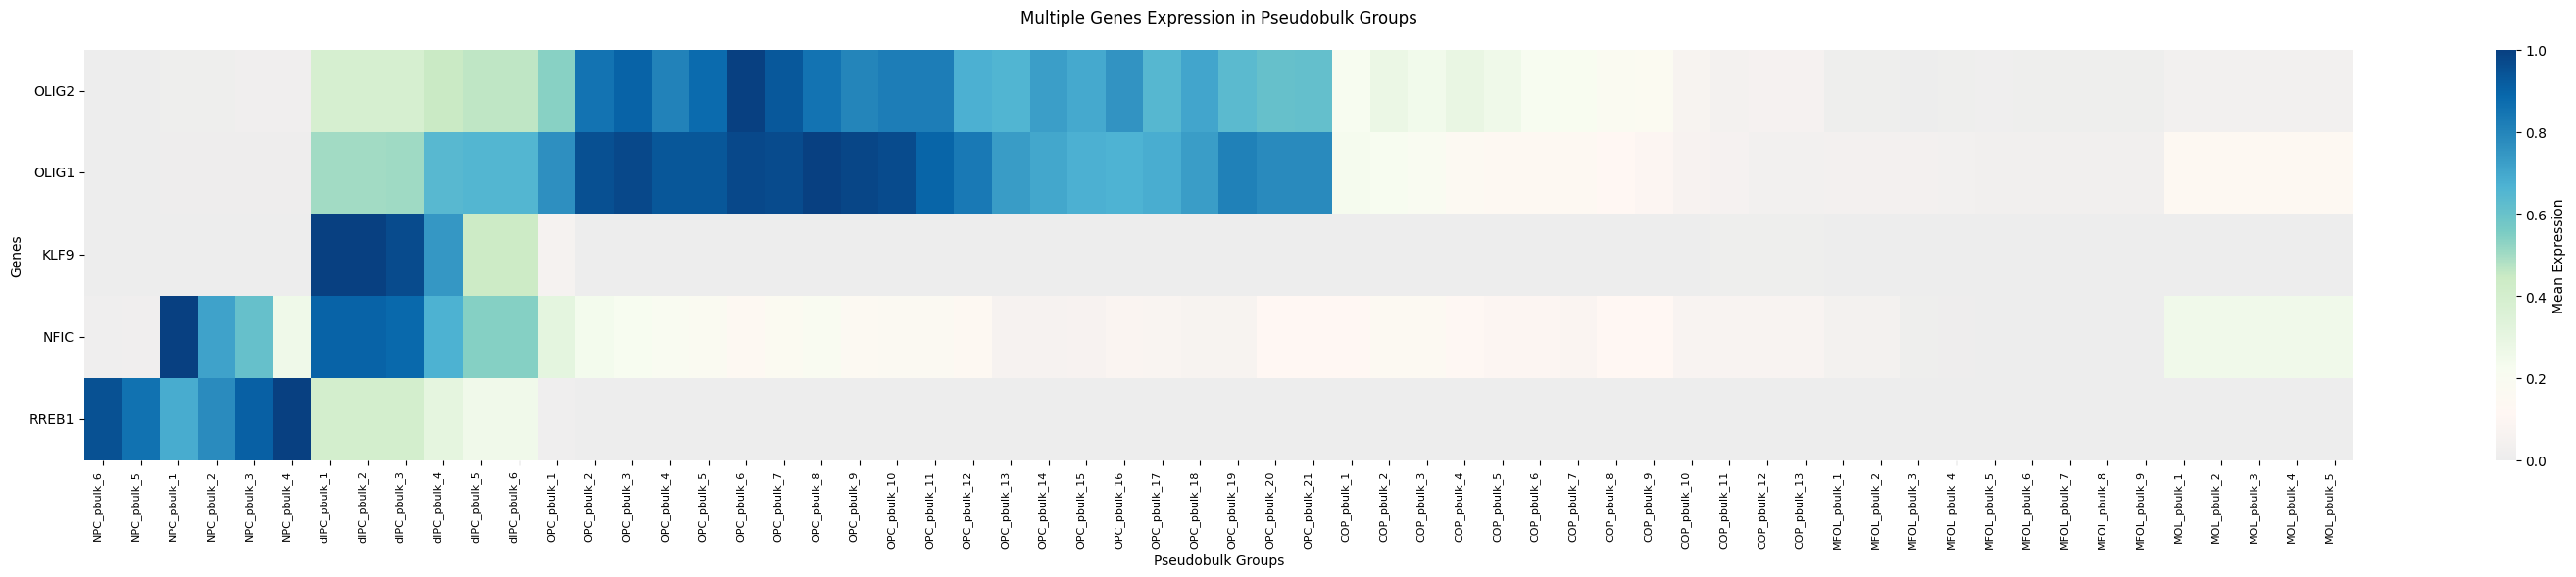

In [ ]:
# gene list
genes_to_plot = ['OLIG2', 'OLIG1', 'KLF9', 'NFIC', 'RREB1']
# matrix
expression_matrix = []
# calculate weighted expression for each gene
for gene in genes_to_plot:
    gene_idx = adata_rna.var_names.get_loc(gene)
    
    # store mean expression for each group
    gene_weighted_values = []
    
    for group in selected_groups:
        group_barcodes = barcode_groups[barcode_groups['group'] == group]['barcode'].tolist()
        cell_indices = adata_rna.obs['group'].isin(group_barcodes)
        
        if cell_indices.sum() > 0:
            # extract expression values
            if sparse.issparse(adata_rna.X):
                exp_values = adata_rna.X[cell_indices, gene_idx]
                if hasattr(exp_values, 'toarray'):
                    exp_values = exp_values.toarray().flatten()
            else:
                exp_values = adata_rna.X[cell_indices, gene_idx].flatten()
            
            # mean expression
            mean_expression = np.mean(exp_values)
            
            # expression frequency 
            expression_threshold = 1
            expressed_cells = (exp_values > expression_threshold).sum()
            expression_frequency = expressed_cells / cell_indices.sum()
            
            # weighted expression = mean expression * expression frequency
            weighted_expression = mean_expression * expression_frequency
            
            # record detailed information
            gene_weighted_values.append(weighted_expression)
        else:
            gene_weighted_values.append(np.nan)
        
    # add current gene result to matrix
    expression_matrix.append(gene_weighted_values)
    print(f"completed gene: {gene}")

# convert to numpy array
expression_matrix = np.array(expression_matrix)
expression_matrix_norm = np.zeros_like(expression_matrix)

for i in range(len(genes_to_plot)):
    row_values = expression_matrix[i, :]
    valid_mask = ~np.isnan(row_values)
    
    if valid_mask.any():
        valid_vals = row_values[valid_mask]
        min_val = np.min(valid_vals)
        max_val = np.max(valid_vals)
        
        if max_val > min_val:
            expression_matrix_norm[i, valid_mask] = (valid_vals - min_val) / (max_val - min_val)
        else:
            expression_matrix_norm[i, valid_mask] = 0.5
    else:
        expression_matrix_norm[i, :] = np.nan

# plot multiple genes heatmap
plt.figure(figsize=(max(len(selected_groups)/2, 10), max(len(genes_to_plot)/2, 6)))
heatmap = sns.heatmap(expression_matrix_norm,
                      cmap=exp_cmap,
                      yticklabels=genes_to_plot,  # y-axis labels are gene names
                      xticklabels=selected_groups,  # x-axis labels are group names
                      cbar_kws={'label': 'Mean Expression'},
                      linecolor=None,
                      square=False,
                      center=None,
                      annot_kws={'size': 6}) 

plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.title('Multiple Genes Expression in Pseudobulk Groups', fontsize=12, pad=20)
plt.xlabel('Pseudobulk Groups', fontsize=10)
plt.ylabel('Genes', fontsize=10)
plt.tight_layout()
plt.savefig('./plot/RNA_oligo1_2_level.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot ATAC value on trajectory

In [95]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac

AnnData object with n_obs × n_vars = 9282 × 141240
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [99]:
adata_atac.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample2,barcode2,celltype,group
TCGTTTCCAACTCGCG-1-7___cisTopic,3143,3.497344,1864,3.270446,cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL,GW20_TCGTTTCCAACTCGCG-1
CCTCCTGAGTTAGTTG-1-7___cisTopic,8423,3.925467,4802,3.681422,cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC,GW20_CCTCCTGAGTTAGTTG-1
CGTCCTAGTAACCTAG-1-1___cisTopic,2279,3.357744,1264,3.101747,cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC,GW12_CGTCCTAGTAACCTAG-1
CATCATGCAGGCCATT-1-6___cisTopic,3443,3.536937,1980,3.296665,cisTopic,GW17,CATCATGCAGGCCATT-1,OPC,GW17_CATCATGCAGGCCATT-1
GAAAGCCAGCTATTGA-1-5___cisTopic,5813,3.764400,3374,3.528145,cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL,GW16_GAAAGCCAGCTATTGA-1
...,...,...,...,...,...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,6306,3.799754,3705,3.568788,cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC,GW16_GTTAACCAGTAAGAAC-1
TACTTCGTCTGTTCAT-1-5___cisTopic,8682,3.938620,4891,3.689398,cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC,GW16_TACTTCGTCTGTTCAT-1
CACAAGCGTTGAGCCG-1-5___cisTopic,4281,3.631545,2560,3.408240,cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP,GW16_CACAAGCGTTGAGCCG-1
TTGCGTCTCCATAAGC-1-5___cisTopic,1302,3.114611,788,2.896526,cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC,GW16_TTGCGTCTCCATAAGC-1


In [98]:
adata_atac.var

,Chromosome,Start,End,Width,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc
RegionIDs,,,,,,,,
chr1:817092-817593,chr1,817092,817593,501,50,1.698970,30,1.477121
chr1:827302-827803,chr1,827302,827803,501,1228,3.089198,706,2.848805
chr1:858597-859098,chr1,858597,859098,501,89,1.949390,53,1.724276
chr1:869671-870172,chr1,869671,870172,501,533,2.726727,287,2.457882
chr1:904519-905020,chr1,904519,905020,501,1049,3.020775,582,2.764923
...,...,...,...,...,...,...,...,...
chrY:19578483-19578984,chrY,19578483,19578984,501,271,2.432969,160,2.204120
chrY:19744468-19744969,chrY,19744468,19744969,501,250,2.397940,162,2.209515
chrY:19892009-19892510,chrY,19892009,19892510,501,133,2.123852,74,1.869232


In [ ]:
# 1. 解析目标区域
target_chr, target_pos = 'chr21:33115188-33115988'.split(':')
target_start, target_end = map(int, target_pos.split('-'))

# 2. 直接筛选
# 条件1: 相同染色体
chr_mask = adata_atac.var['Chromosome'] == target_chr
# 条件2: 区域有重叠 (结束位置 >= 目标起始位置 AND 起始位置 <= 目标结束位置)
overlap_mask = (adata_atac.var['End'] >= target_start) & (adata_atac.var['Start'] <= target_end)

# 3. 组合条件
overlap_peaks = adata_atac.var[chr_mask & overlap_mask]

# 4. 显示结果
print(f"与 chr21:33115188-33115988 有交集的peaks数量: {len(overlap_peaks)}")
overlap_peaks

与 chr21:33115188-33115988 有交集的peaks数量: 3


,Chromosome,Start,End,Width,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc
RegionIDs,,,,,,,,
chr21:33115805-33116306,chr21,33115805,33116306,501,2169,3.336260,1221,3.086716
chr21:33117365-33117866,chr21,33117365,33117866,501,2580,3.411620,1383,3.140822
chr21:33116626-33117127,chr21,33116626,33117127,501,2016,3.304491,1160,3.064458


In [ ]:
region = 'chr21:33115805-33116306'

In [ ]:
# adata_atac.layers['counts'] = adata_atac.X.copy()
# sc.pp.normalize_total(adata_atac)
# sc.pp.log1p(adata_atac)

In [102]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_CTTTGAGCATTGACAT-1,COP_pbulk_1
1,GW16_ACCTACCTCCCGTTGT-1,COP_pbulk_1
2,GW20_ATATGGTGTTTGAGGC-1,COP_pbulk_1
3,GW16_CAAGGTTTCCCTGACT-1,COP_pbulk_1
4,GW16_ATGGCTAGTAACGAGG-1,COP_pbulk_1
...,...,...
48219,GW20_GGACATAAGTGCTGTG-1,dIPC_pbulk_6
48220,GW12_GGAACCACAGCAAGAT-1,dIPC_pbulk_6
48221,GW17_TGTGCGGGTTACAACG-1,dIPC_pbulk_6
48222,GW17_GGAACAATCAAGTGTC-1,dIPC_pbulk_6


In [103]:
selected_groups=['NPC_pbulk_6', 'NPC_pbulk_5', 'NPC_pbulk_1', 'NPC_pbulk_2', 'NPC_pbulk_3', 'NPC_pbulk_4', 
                 'dIPC_pbulk_1', 'dIPC_pbulk_2', 'dIPC_pbulk_3', 'dIPC_pbulk_4', 'dIPC_pbulk_5', 'dIPC_pbulk_6',
                 'OPC_pbulk_1', 'OPC_pbulk_2', 'OPC_pbulk_3', 'OPC_pbulk_4', 'OPC_pbulk_5', 'OPC_pbulk_6', 'OPC_pbulk_7', 'OPC_pbulk_8', 'OPC_pbulk_9', 'OPC_pbulk_10', 'OPC_pbulk_11', 'OPC_pbulk_12', 'OPC_pbulk_13', 'OPC_pbulk_14', 'OPC_pbulk_15', 'OPC_pbulk_16', 'OPC_pbulk_17', 'OPC_pbulk_18', 'OPC_pbulk_19','OPC_pbulk_20', 'OPC_pbulk_21', 
                 'COP_pbulk_1', 'COP_pbulk_2', 'COP_pbulk_3', 'COP_pbulk_4', 'COP_pbulk_5', 'COP_pbulk_6', 'COP_pbulk_7', 'COP_pbulk_8', 'COP_pbulk_9', 'COP_pbulk_10', 'COP_pbulk_11', 'COP_pbulk_12', 'COP_pbulk_13',
                 'MFOL_pbulk_1', 'MFOL_pbulk_2', 'MFOL_pbulk_3', 'MFOL_pbulk_4', 'MFOL_pbulk_5', 'MFOL_pbulk_6', 'MFOL_pbulk_7', 'MFOL_pbulk_8', 'MFOL_pbulk_9',
                 'MOL_pbulk_1', 'MOL_pbulk_2', 'MOL_pbulk_3', 'MOL_pbulk_4', 'MOL_pbulk_5', 
                 ]

completed region: chr21:33115488-33115988 -> chr21:33115805-33116306


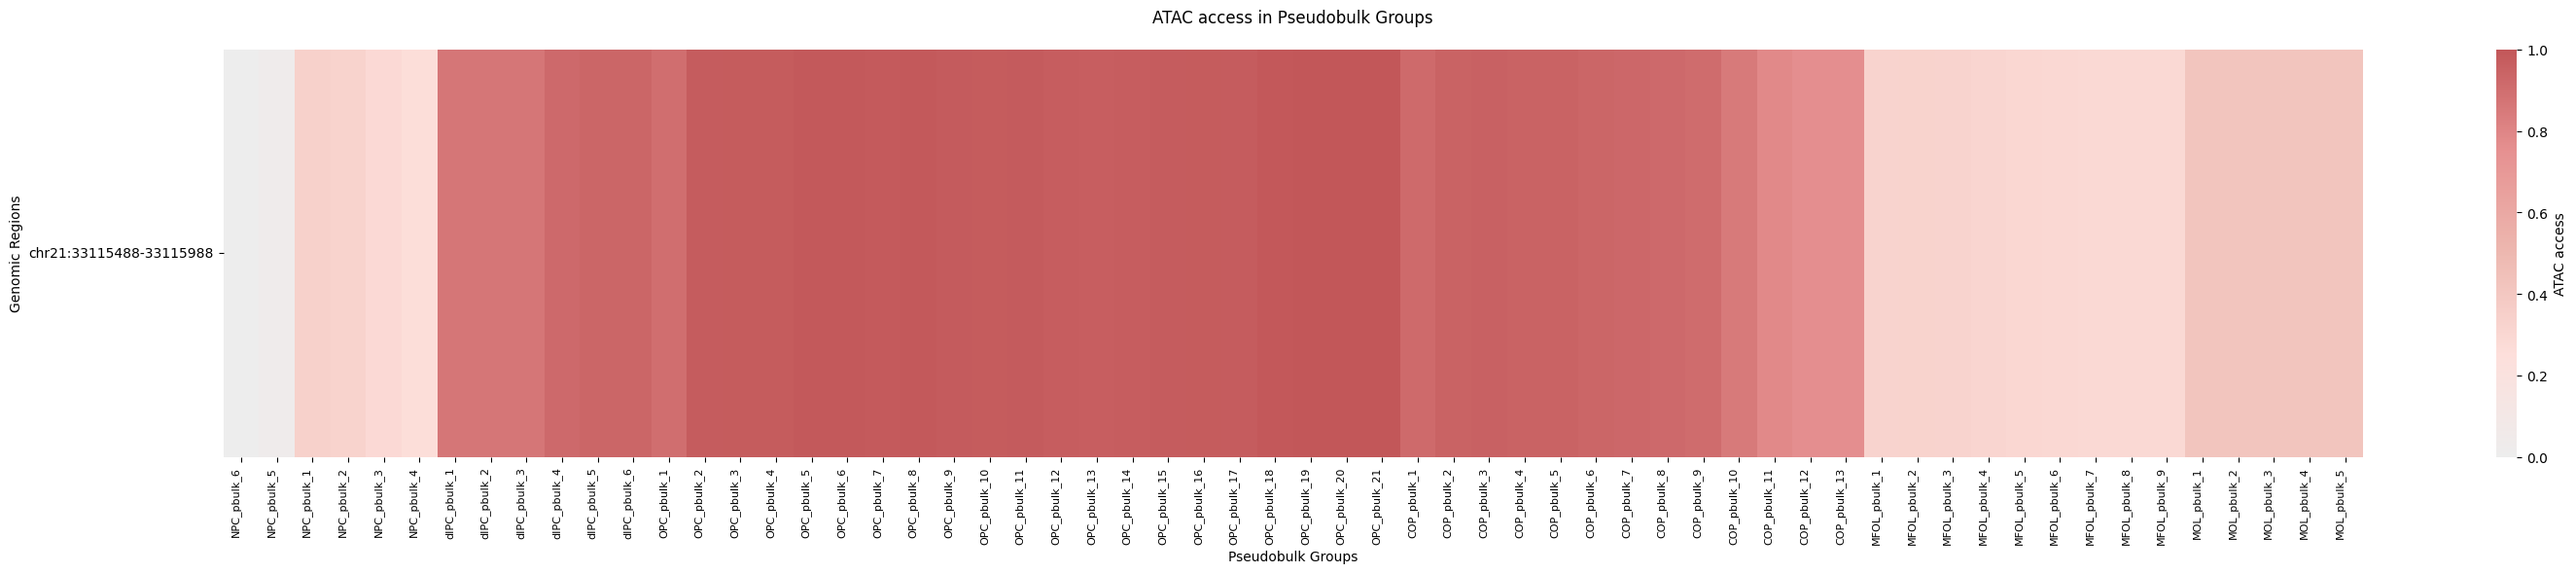

In [136]:
# region list
regions_to_plot = ['chr21:33115488-33115988']
# matrix
access_matrix = []
# calculate weighted access for each region
for region in regions_to_plot:
    target_chr, target_pos = region.split(':')
    target_start, target_end = map(int, target_pos.split('-'))
    
    # find peak
    peak_mask = (adata_atac.var['Chromosome'] == target_chr) & \
                (adata_atac.var['End'] >= target_start) & \
                (adata_atac.var['Start'] <= target_end)
    
    if peak_mask.sum() > 0:
        # use first overlapping peak
        peak_name = adata_atac.var_names[peak_mask][0]
        peak_idx = adata_atac.var_names.get_loc(peak_name)
        
        region_weighted_values = []
        
        for group in selected_groups:
            group_barcodes = barcode_groups[barcode_groups['group'] == group]['barcode'].tolist()
            cell_indices = adata_atac.obs['group'].isin(group_barcodes)
            
            if cell_indices.sum() > 0:
                if sparse.issparse(adata_atac.X):
                    access_values = adata_atac.X[cell_indices, peak_idx]
                    if hasattr(access_values, 'toarray'):
                        access_values = access_values.toarray().flatten()
                else:
                    access_values = adata_atac.X[cell_indices, peak_idx].flatten()
                
                # mean access
                mean_access = np.mean(access_values)
                
                # access frequency
                access_threshold = 0
                open_cells = (access_values > access_threshold).sum()
                access_frequency = open_cells / cell_indices.sum()
                
                # weighted access = mean access * access frequency
                weighted_access = mean_access * access_frequency
                
                region_weighted_values.append(weighted_access)
            else:
                region_weighted_values.append(np.nan)
        
        access_matrix.append(region_weighted_values)
        print(f"completed region: {region} -> {peak_name}")
    else:
        access_matrix.append([np.nan] * len(selected_groups))
        print(f"no peak found for region: {region}")

# convert to numpy array
access_matrix = np.array(access_matrix)
access_matrix_norm = np.zeros_like(access_matrix)

for i in range(len(regions_to_plot)):
    row_values = access_matrix[i, :]
    valid_mask = ~np.isnan(row_values)
    
    if valid_mask.any():
        valid_vals = row_values[valid_mask]
        min_val = np.min(valid_vals)
        max_val = np.max(valid_vals)
        
        if max_val > min_val:
            access_matrix_norm[i, valid_mask] = (valid_vals - min_val) / (max_val - min_val)
        else:
            access_matrix_norm[i, valid_mask] = 0.5
    else:
        access_matrix_norm[i, :] = np.nan

# plot multiple regions heatmap
plt.figure(figsize=(max(len(selected_groups)/2, 10), max(len(regions_to_plot)/2, 6)))
heatmap = sns.heatmap(access_matrix_norm,
                      cmap=acc_cmap,
                      yticklabels=regions_to_plot,
                      xticklabels=selected_groups,
                      cbar_kws={'label': 'ATAC access'},
                      linecolor=None,
                      square=False,
                      center=None,
                      annot_kws={'size': 6})

plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.title('ATAC access in Pseudobulk Groups', fontsize=12, pad=20)
plt.xlabel('Pseudobulk Groups', fontsize=10)
plt.ylabel('Genomic Regions', fontsize=10)
plt.tight_layout()
plt.savefig('./plot/ATAC_oligo_1_2_signal.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot Gene-Peak links on trajectory

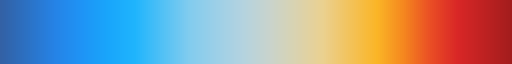

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

ATAC_colors = ["#3361A5", "#2C72C5", "#2683E6", "#1F94F6", "#19A6FB", "#20B5FD", "#51C1F6", "#81CCEF", "#9CD0E8", "#B4D3E0", "#C9D4CD", "#DAD3B0", "#EBD190", "#F3C35B", "#FBB627", "#F5871F", "#EA4E25", "#D92727", "#BE2222", "#A31D1D"]
ATAC_cmap = LinearSegmentedColormap.from_list("my_cmap", ATAC_colors, N=256)
ATAC_cmap

In [2]:
import mudata
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
scplus_mdata

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

MuData object with n_obs × n_vars = 10248 × 199435
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	10248 x 36601
      obs:	'sample2', 'barcode2', 'celltype'
      var:	'gene_ids', 'feature_types'
    scATAC_counts:	10248 x 162500
      obs:	'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	10248 x 92
    direct_region_based_AUC:	10248 x 92
    extended_gene_based_AUC:	10248 x 75
    extended_region_based_AUC:	10248 x 75

In [3]:
adata_rna = scplus_mdata.mod['scRNA_counts']
adata_rna.obs['group'] = adata_rna.obs['sample2'].astype(str) + '_' + adata_rna.obs['barcode2'].astype(str)
adata_rna

AnnData object with n_obs × n_vars = 10248 × 36601
    obs: 'sample2', 'barcode2', 'celltype', 'group'
    var: 'gene_ids', 'feature_types'

In [4]:
adata_atac = scplus_mdata.mod['scATAC_counts']
adata_atac.obs['group'] = adata_atac.obs['sample2'].astype(str) + '_' + adata_atac.obs['barcode2'].astype(str)
adata_atac

AnnData object with n_obs × n_vars = 10248 × 162500
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample2', 'barcode2', 'celltype', 'group'
    var: 'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'

In [5]:
adata_atac.obs

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample2,barcode2,celltype,group
CTGACCAAGCATGTTA-1-4___cisTopic,6214,3.793371,3549,3.550106,cisTopic,GW10,CTGACCAAGCATGTTA-1,ExN_naive,GW10_CTGACCAAGCATGTTA-1
GGCCATCAGGGACCTC-1-6___cisTopic,6063,3.782688,3702,3.568436,cisTopic,GW17,GGCCATCAGGGACCTC-1,OPC,GW17_GGCCATCAGGGACCTC-1
AATCGCCCAATTAGGA-1-2___cisTopic,2084,3.318898,1247,3.095866,cisTopic,GW7,AATCGCCCAATTAGGA-1,ExN_naive,GW7_AATCGCCCAATTAGGA-1
AGGACGTAGGAAACTG-1-1___cisTopic,12127,4.083753,5945,3.774152,cisTopic,GW12,AGGACGTAGGAAACTG-1,OPC,GW12_AGGACGTAGGAAACTG-1
CCAGGAACAATCCTAG-1-4___cisTopic,5374,3.730298,3142,3.497206,cisTopic,GW10,CCAGGAACAATCCTAG-1,ExN_naive,GW10_CCAGGAACAATCCTAG-1
...,...,...,...,...,...,...,...,...,...
TCCTTAGTCGCTAGCA-1-5___cisTopic,19751,4.295589,10451,4.019158,cisTopic,GW16,TCCTTAGTCGCTAGCA-1,NPC,GW16_TCCTTAGTCGCTAGCA-1
CCTGGATCACAAAGAC-1-5___cisTopic,4765,3.678063,2746,3.438701,cisTopic,GW16,CCTGGATCACAAAGAC-1,OPC,GW16_CCTGGATCACAAAGAC-1
CTGTACCTCCGTGACA-1-7___cisTopic,7148,3.854185,4154,3.618466,cisTopic,GW20,CTGTACCTCCGTGACA-1,OPC,GW20_CTGTACCTCCGTGACA-1
ATGAAGCCAGCTTAAT-1-1___cisTopic,13415,4.127591,6422,3.807670,cisTopic,GW12,ATGAAGCCAGCTTAAT-1,ExN_naive,GW12_ATGAAGCCAGCTTAAT-1


In [6]:
import pandas as pd
import numpy as np
import ast 

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/region_to_gene_adj.tsv",sep = '\t')
region_df = region_to_gene.copy()
# prepare the distance column
def parse_distance(x):
    if isinstance(x, str):
        try:
            return abs(ast.literal_eval(x)[0])
        except:
            return 999999999
    elif isinstance(x, list):
        return abs(x[0])
    return abs(x)

region_df['abs_distance'] = region_df['Distance'].apply(parse_distance)

# set the filtering threshold
# condition 1: must be positively correlated (Open chromatin -> Gene Expression)
# set a slightly higher threshold 0.03, filter out very weak correlations
cond_rho = region_df['rho'] > 0.03 

# condition 2: Importance must be high
# strategy: take the 50th percentile of Importance (keep top 50% strong connections)
importance_cutoff = region_df['importance'].quantile(0.5)
cond_imp = region_df['importance'] > importance_cutoff

# condition 3: distance should not be too far
cond_dist = region_df['abs_distance'] < 500000


# filtering
region_filtered = region_df[cond_rho & cond_imp & cond_dist].copy()
print(f"original number of connections: {len(region_df)}")
print(f"number of connections after filtering: {len(region_filtered)}")

# preview
region_filtered.head()

original number of connections: 454774
number of connections after filtering: 59622


,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance
18,A2ML1,chr12:8682012-8682513,0.036686,0.032569,0.001195,0.001195,[140359],140359
19,A2ML1,chr12:8687712-8688213,0.070203,0.069099,0.004851,0.004851,[134659],134659
20,A2ML1,chr12:8689692-8690193,0.061036,0.070448,0.004300,0.004300,[132679],132679
24,A2ML1,chr12:8780361-8780862,0.096342,0.094890,0.009142,0.009142,[42009],42009
25,A2ML1,chr12:8823850-8824351,0.153742,0.086210,0.013254,0.013254,[0],0


In [7]:
barcode_groups = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Neuron/seq2print/barcode_groups_latent_time_based.csv', sep=',', header=0)[['barcode','group']]
barcode_groups

,barcode,group
0,GW9_TCAGCGATCTTGTTCG-1,ExN_ExN_naive_pbulk_1
1,GW9_CTTGTCCAGTGACCTG-1,ExN_ExN_naive_pbulk_1
2,GW7_CAAGTGAAGGCCGGAA-1,ExN_ExN_naive_pbulk_1
3,GW9_GTAGGAGGTCCGTGAG-1,ExN_ExN_naive_pbulk_1
4,GW7_TAGCTAGGTAGGTGTC-1,ExN_ExN_naive_pbulk_1
...,...,...
38650,GW12_CTTAAGATCTCTAGCC-1,Oligo_dIPC_switching_pbulk_1
38651,GW12_GGATTTATCACCGGTA-1,Oligo_dIPC_switching_pbulk_1
38652,GW12_TTTCTTGCATCCGTAA-1,Oligo_dIPC_switching_pbulk_1
38653,GW12_TCTCAAGCAGGCCATT-1,Oligo_dIPC_switching_pbulk_1


In [8]:
# 1. 定义三个谱系的 Bulk 顺序列表
exn_order = [
    'ExN_NPC_pbulk_1', 'ExN_NPC_pbulk_2', 'ExN_NPC_pbulk_3', 'ExN_NPC_pbulk_4', 'ExN_NPC_pbulk_5', 'ExN_NPC_pbulk_6', 'ExN_NPC_pbulk_7',
    'ExN_dIPC_pbulk_1', 'ExN_dIPC_pbulk_2', 'ExN_dIPC_pbulk_3', 'ExN_dIPC_pbulk_4',
    'ExN_dIPC_switching_pbulk_1',
    'ExN_ExN_naive_pbulk_1', 'ExN_ExN_naive_pbulk_2', 'ExN_ExN_naive_pbulk_3', 'ExN_ExN_naive_pbulk_4', 'ExN_ExN_naive_pbulk_5', 'ExN_ExN_naive_pbulk_6', 'ExN_ExN_naive_pbulk_7', 'ExN_ExN_naive_pbulk_8'
]

inn_order = [
    'InN_NPC_pbulk_1', 'InN_NPC_pbulk_2', 'InN_NPC_pbulk_3', 'InN_NPC_pbulk_4', 'InN_NPC_pbulk_5', 'InN_NPC_pbulk_6', 'InN_NPC_pbulk_7', 'InN_NPC_pbulk_8', 'InN_NPC_pbulk_9',
    'InN_dIPC_pbulk_1', 'InN_dIPC_pbulk_2', 'InN_dIPC_pbulk_3', 'InN_dIPC_pbulk_4', 'InN_dIPC_pbulk_5', 'InN_dIPC_pbulk_6',
    'InN_dIPC_switching_pbulk_1',
    'InN_InN_naive_pbulk_1', 'InN_InN_naive_pbulk_2', 'InN_InN_naive_pbulk_3', 'InN_InN_naive_pbulk_4'
]

oligo_order = [
    'Oligo_NPC_pbulk_1',
    'Oligo_dIPC_switching_pbulk_1',
    'Oligo_dIPC_switched_pbulk_1', 'Oligo_dIPC_switched_pbulk_2', 'Oligo_dIPC_switched_pbulk_3', 'Oligo_dIPC_switched_pbulk_4',
    'Oligo_OPC_pbulk_1', 'Oligo_OPC_pbulk_2', 'Oligo_OPC_pbulk_3', 'Oligo_OPC_pbulk_4', 'Oligo_OPC_pbulk_5', 'Oligo_OPC_pbulk_6', 'Oligo_OPC_pbulk_7', 'Oligo_OPC_pbulk_8', 'Oligo_OPC_pbulk_9', 'Oligo_OPC_pbulk_10', 'Oligo_OPC_pbulk_11', 'Oligo_OPC_pbulk_12', 'Oligo_OPC_pbulk_13', 'Oligo_OPC_pbulk_14'
]

lineage_dict = {
    'ExN': exn_order,
    'InN': inn_order,
    'Oligo': oligo_order
}

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr
from scipy.ndimage import gaussian_filter1d
import os

# 2. 定义核心函数：谱系特异性筛选
# ==========================================
def get_lineage_specific_links(global_links, rna_df, atac_df, lineage_cols, min_corr=0.25):
    """
    在特定谱系中重新计算相关性，筛选真正活跃的 Links
    """
    # 截取该谱系的列
    valid_cols = [c for c in lineage_cols if c in rna_df.columns and c in atac_df.columns]
    curr_rna = rna_df[valid_cols]
    curr_atac = atac_df[valid_cols]
    
    # 只要 global list 里的基因和 region 都在矩阵里就可以算
    valid_links = global_links[
        global_links['target'].isin(curr_rna.index) & 
        global_links['region'].isin(curr_atac.index)
    ].copy()
    
    # 向量化计算相关性 (Fast Pearson)
    targets = valid_links['target'].values
    regions = valid_links['region'].values
    
    rna_mat = curr_rna.loc[targets].values
    atac_mat = curr_atac.loc[regions].values
    
    # Row-wise centering
    rna_centered = rna_mat - rna_mat.mean(axis=1, keepdims=True)
    atac_centered = atac_mat - atac_mat.mean(axis=1, keepdims=True)
    
    # Cosine similarity
    numer = np.sum(rna_centered * atac_centered, axis=1)
    denom = np.sqrt(np.sum(rna_centered**2, axis=1)) * np.sqrt(np.sum(atac_centered**2, axis=1))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        corrs = numer / denom
        
    valid_links['lineage_corr'] = corrs
    
    # 筛选：相关性 > min_corr (建议比全局阈值高一点，例如 0.25 或 0.3)
    specific_links = valid_links[valid_links['lineage_corr'] > min_corr].copy()
    
    return specific_links, curr_rna, curr_atac


# Pseudobulk 
def compute_pseudobulk(adata, group_dict, order_list, match_col='group'):
    """
    adata: scRNA or scATAC object
    group_dict: {group_name: [barcode1, barcode2, ...]}
    order_list: list of group names
    match_col: column name in adata.obs for matching barcodes
    """
    print(f"Start processing {len(order_list)} groups...")
    
    # set match_col as temporary index to accelerate .loc lookup, or use boolean mask directly
    available_barcodes = set(adata.obs[match_col])
    results = []
    valid_groups = []
    
    for group_name in order_list:
        # get the theoretically expected barcodes from the external dictionary
        target_barcodes = group_dict.get(group_name, [])
        
        # take intersection: only keep cells that actually exist in adata
        valid_cells = [b for b in target_barcodes if b in available_barcodes]
        
        if len(valid_cells) == 0:
            # if this group is not found in the current adata, skip or fill 0
            continue
            
        # extract cells & calculate mean
        subset_mask = adata.obs[match_col].isin(valid_cells)
        subset_X = adata[subset_mask].X
        
        # calculate mean & flatten
        mean_val = subset_X.mean(axis=0)
        mean_exp = np.ravel(mean_val) # compatible with sparse matrix
        
        results.append(mean_exp)
        valid_groups.append(group_name)
        
    # DataFrame
    pb_df = pd.DataFrame(results, index=valid_groups, columns=adata.var_names).T
    
    print(f"Computed {len(valid_groups)} groups out of {len(order_list)} requested.")
    return pb_df, valid_groups

In [10]:
# 将三个列表合并成一个总列表
all_lineage_order = exn_order + inn_order + oligo_order
len(all_lineage_order)

60

In [11]:
# 确保使用我们在上一步生成的 barcode_groups_df
group_to_barcodes = barcode_groups.groupby('group')['barcode'].apply(list).to_dict()
len(group_to_barcodes)

60

In [12]:
# 重新计算 RNA Pseudobulk
print("Re-computing RNA pseudobulks for ALL lineages...")
rna_pb, valid_groups_rna = compute_pseudobulk(
    adata_rna, 
    group_to_barcodes, 
    all_lineage_order, # 使用合并后的总列表
    match_col='group'  # 注意：你需要确保 adata_rna.obs 里没有旧的 'group' 列干扰，或者字典匹配正确
)

# 重新计算 ATAC Pseudobulk
print("Re-computing ATAC pseudobulks for ALL lineages...")
atac_pb, valid_groups_atac = compute_pseudobulk(
    adata_atac, 
    group_to_barcodes, 
    all_lineage_order, # 使用合并后的总列表
    match_col='group'
)

# 确保列名对齐
final_groups = sorted(list(set(valid_groups_rna).intersection(valid_groups_atac)), key=lambda x: all_lineage_order.index(x))
rna_pb = rna_pb[final_groups]
atac_pb = atac_pb[final_groups]

print(f"Final RNA shape: {rna_pb.shape}")
print(f"Final ATAC shape: {atac_pb.shape}")
# 检查一下列名是否包含 InN
print("Check InN columns:", [c for c in rna_pb.columns if 'InN' in c][:3])

Re-computing RNA pseudobulks for ALL lineages...
Start processing 60 groups...
Computed 60 groups out of 60 requested.
Re-computing ATAC pseudobulks for ALL lineages...
Start processing 60 groups...
Computed 60 groups out of 60 requested.
Final RNA shape: (36601, 60)
Final ATAC shape: (162500, 60)
Check InN columns: ['InN_NPC_pbulk_1', 'InN_NPC_pbulk_2', 'InN_NPC_pbulk_3']



Processing Lineage: ExN
  -> Found 33737 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 4874 bad links.
  -> Final Links for plotting: 28863
  -> Links saved to CSV: ./outs/peak_gene_links_ExN.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_ExN.pdf


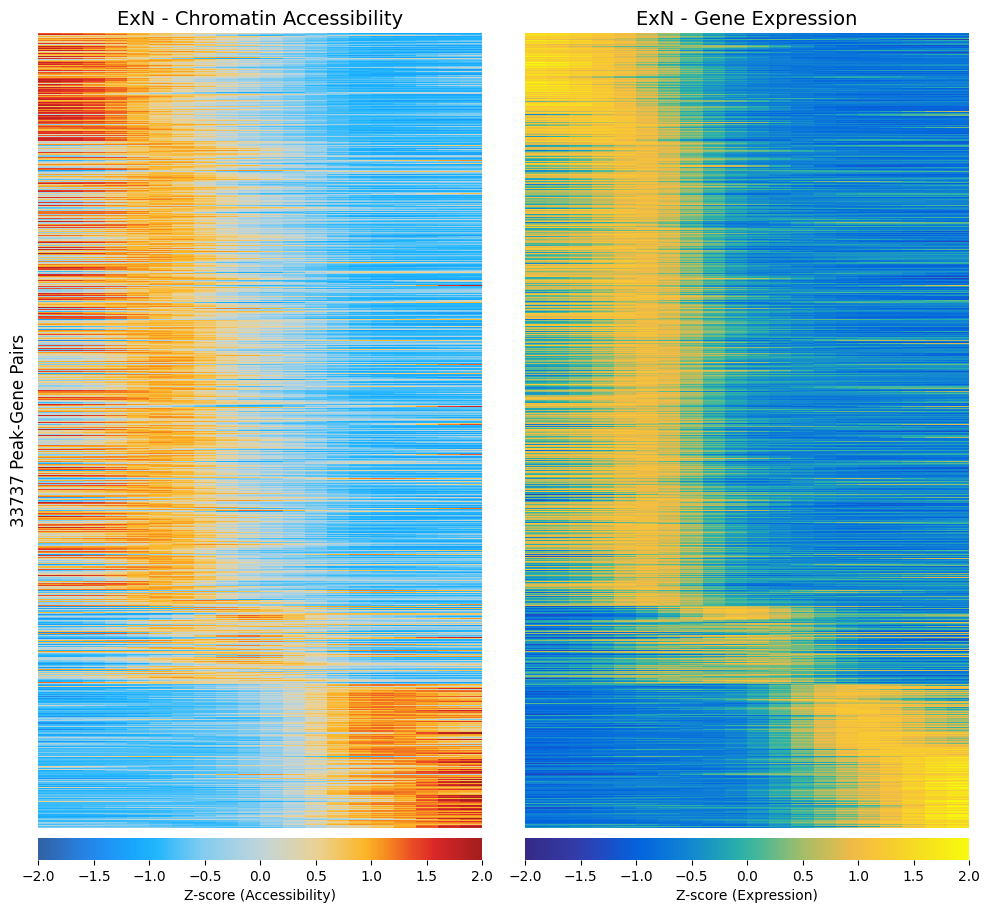


Processing Lineage: InN
  -> Found 33833 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 4853 bad links.
  -> Final Links for plotting: 28980
  -> Links saved to CSV: ./outs/peak_gene_links_InN.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_InN.pdf


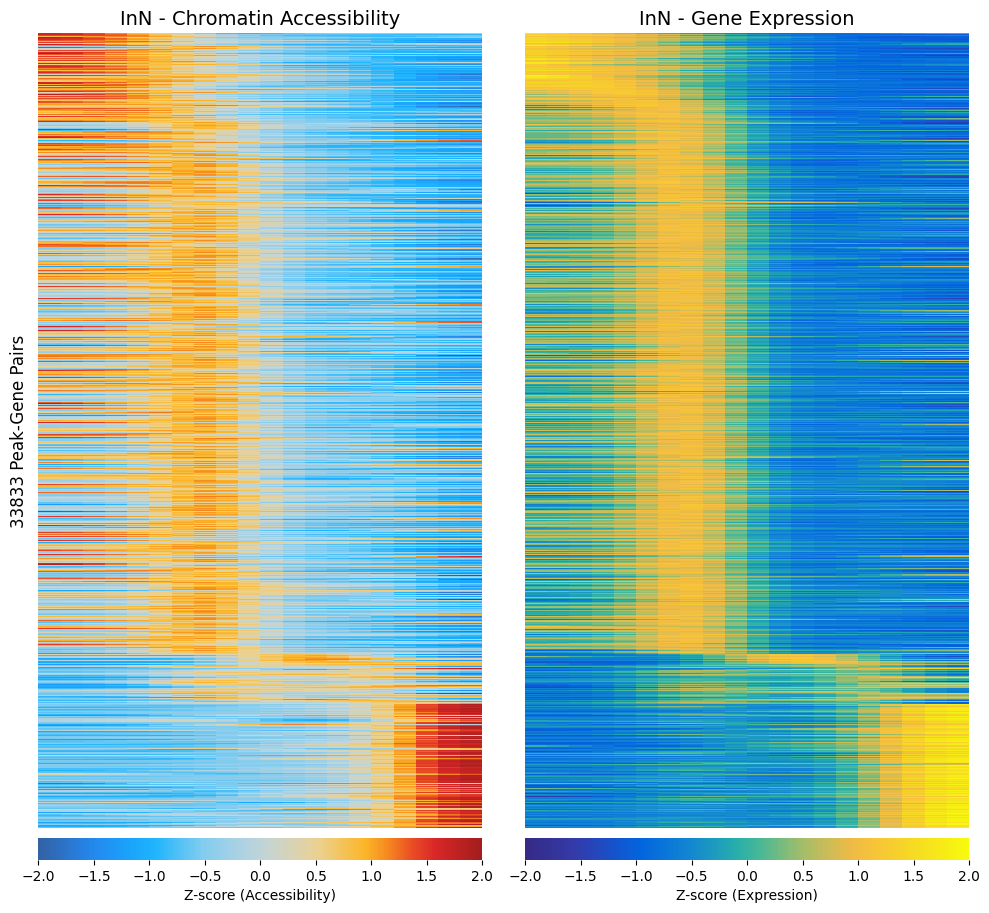


Processing Lineage: Oligo
  -> Found 32495 specific links (correlation > 0.5)
  -> Quality Filtering: Removed 7356 bad links.
  -> Final Links for plotting: 25139
  -> Links saved to CSV: ./outs/peak_gene_links_Oligo.csv
  -> Plot saved to: ./plot/peak_gene_dynamics_Oligo.pdf


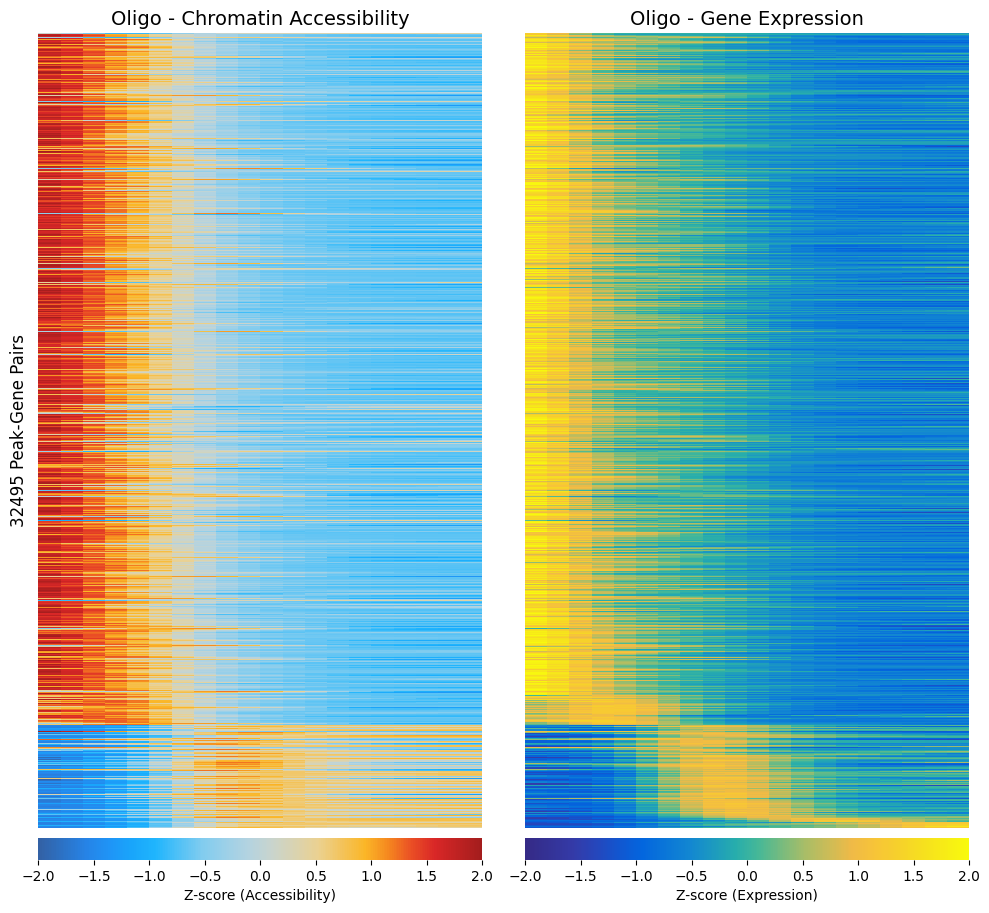

In [ ]:

for lineage_name, order_list in lineage_dict.items():
    print(f"\n{'='*40}")
    print(f"Processing Lineage: {lineage_name}")
    
    # --- Step A: 重新筛选 Links ---
    lin_links, lin_rna, lin_atac = get_lineage_specific_links(
        region_filtered, rna_pb, atac_pb, order_list, min_corr=0.5
    )
    
    n_links = len(lin_links)
    print(f"  -> Found {n_links} specific links (correlation > 0.5)")
    
    # 1. 预提取 RNA 矩阵用于计算质量指标
    temp_rna = lin_rna.loc[lin_links['target']].values
    temp_z = np.nan_to_num(zscore(temp_rna, axis=1))
    
    # --- 过滤标准 1: 信号强度 (Signal Strength) ---
    # 如果一个基因的 Z-score 最大值都很小 (比如 < 1.0)，说明它在全过程中几乎没变化，全是背景噪音
    max_z_scores = np.max(temp_z, axis=1)
    keep_strong_signal = max_z_scores > 1.5 
    
    # --- 过滤标准 2: 峰值一致性 (Peak Consistency) ---
    # 解决 "晚期基因因为其实噪音被排在前面" 的核心方法
    # 计算 Argmax (最高点)
    peak_indices = np.argmax(temp_z, axis=1)
    
    # 计算重心 (Center of Mass)
    temp_pos = np.maximum(temp_z, 0)
    mass = np.sum(temp_pos, axis=1)
    mass[mass == 0] = 1e-9
    x_axis = np.arange(temp_z.shape[1])
    com_indices = np.sum(temp_pos * x_axis, axis=1) / mass
    
    # 如果 (最高点 - 重心) 的距离太大，说明数据分布很奇怪（例如双峰，或者有一个远离主峰的噪音刺）
    # 设定允许的偏差范围 (例如：总长度的 25% ~ 30%，约 5-6 个格子)
    diff = np.abs(peak_indices - com_indices)
    keep_consistent = diff < 5.0  
    
    # --- 执行过滤 ---
    final_mask = keep_strong_signal & keep_consistent
    lin_links = lin_links[final_mask].copy()
    
    print(f"  -> Quality Filtering: Removed {np.sum(~final_mask)} bad links.")
    print(f"  -> Final Links for plotting: {len(lin_links)}")
    
    if len(lin_links) < 10:
        print("  -> Too few links after QC, skipping.")
        continue


    # --- Step B: 准备矩阵 (Z-score & Sorting) ---
    # 提取 Raw Data
    mat_rna_raw = lin_rna.loc[lin_links['target']].values
    mat_atac_raw = lin_atac.loc[lin_links['region']].values
    
    # Z-score (横向标准化)
    mat_rna_z = np.nan_to_num(zscore(mat_rna_raw, axis=1))
    mat_atac_z = np.nan_to_num(zscore(mat_atac_raw, axis=1))
    
    # Sorting: 按照 RNA 表达峰值时间排序
    # argmax 取最大值法
    peak_time_rna = np.argmax(mat_rna_z, axis=1)
    sorted_indices = np.argsort(peak_time_rna)
    
    mat_rna_sorted = mat_rna_z[sorted_indices, :]
    mat_atac_sorted = mat_atac_z[sorted_indices, :]
    
    # 保存排序后的 Links 到 CSV
    # 使用 sorted_indices 对 DataFrame 进行重排，使其顺序与热图完全一致
    lin_links_sorted = lin_links.iloc[sorted_indices].copy()
        
    # 保存文件
    csv_path = f"./outs/peak_gene_links_{lineage_name}.csv"
    lin_links_sorted.to_csv(csv_path, index=False, sep=',')
    print(f"  -> Links saved to CSV: {csv_path}")

    # Smoothing
    sigma_val = 2.0
    mat_rna_plot = gaussian_filter1d(mat_rna_sorted, sigma=sigma_val, axis=1)
    mat_atac_plot = gaussian_filter1d(mat_atac_sorted, sigma=sigma_val, axis=1)
    
    # --- Step C: 绘图 (完全复用你的代码逻辑) ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
    vmin, vmax = -2.0, 2.0

    # ATAC Plot
    sns.heatmap(mat_atac_plot, cmap=ATAC_cmap, vmin=vmin, vmax=vmax, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Z-score (Accessibility)', 'location': 'bottom', 'pad':0.01},
                ax=axes[0],
                rasterized=True)
    axes[0].set_title(f'{lineage_name} - Chromatin Accessibility', fontsize=14)
    axes[0].set_xlabel('Pseudotime (Groups)', fontsize=12)
    axes[0].set_ylabel(f'{n_links} Peak-Gene Pairs', fontsize=12)

    # RNA Plot
    sns.heatmap(mat_rna_plot, cmap=RNA_cmap, vmin=vmin, vmax=vmax, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Z-score (Expression)', 'location': 'bottom', 'pad':0.01},
                ax=axes[1],
                rasterized=True)
    axes[1].set_title(f'{lineage_name} - Gene Expression', fontsize=14)
    axes[1].set_xlabel('Pseudotime (Groups)', fontsize=12)

    plt.tight_layout()
    
    # 动态生成文件名
    save_path = f"./plot/peak_gene_dynamics_{lineage_name}.pdf"
    plt.savefig(save_path, dpi=300)
    print(f"  -> Plot saved to: {save_path}")
    
    plt.show()
    plt.close() # 关闭画布释放内存

# Differences in the process of neural subtype determination

## part 1 in neuron

In [3]:
ExN_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_ExN.csv')
InN_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_InN.csv')
Oligo_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_Oligo.csv')
ExN_links.head()

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr
0,NUBPL,chr14:31962910-31963411,0.080986,0.134431,0.010887,0.010887,[-101936],101936,0.878002
1,THOC1,chr18:286379-286880,0.056028,0.053871,0.003018,0.003018,[18580],18580,0.705171
2,THOC1,chr18:305011-305512,0.091673,0.050323,0.004613,0.004613,[37212],37212,0.755463
3,ARHGAP11A,chr15:32730626-32731127,0.027555,0.075908,0.002092,0.002092,[-90935],90935,0.897311
4,KNOP1,chr16:19745203-19745704,0.039257,0.100808,0.003957,0.003957,[27219],27219,0.923684


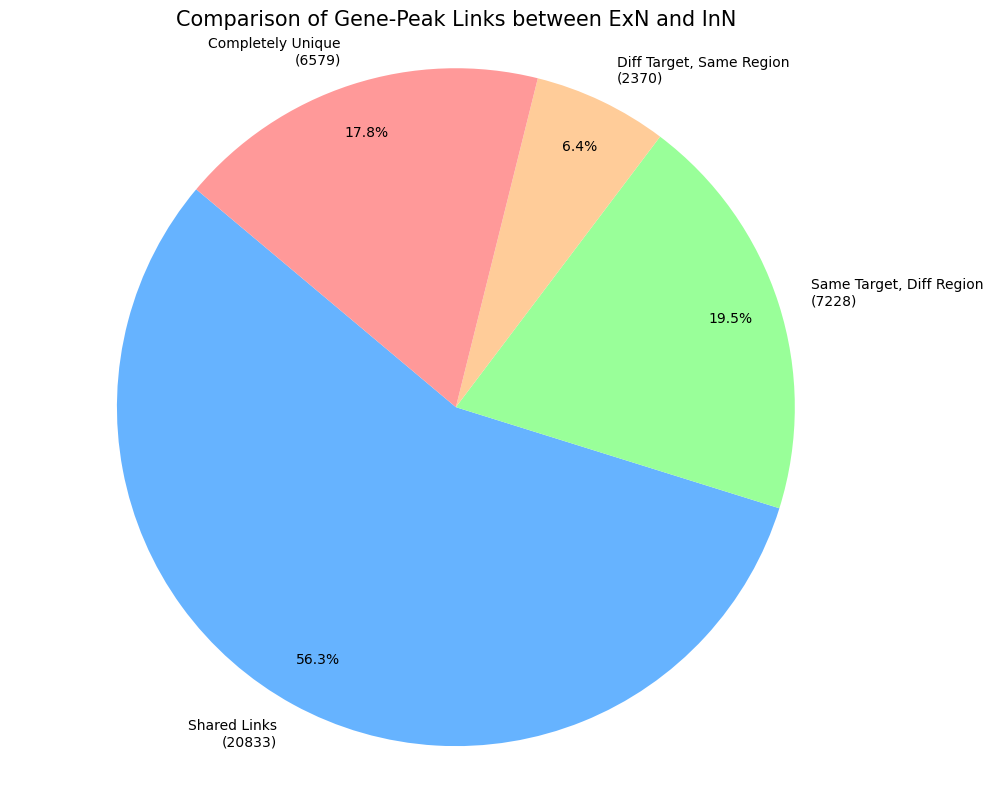

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 构造唯一标识符
ExN_links['link_id'] = ExN_links['target'] + "_" + ExN_links['region']
InN_links['link_id'] = InN_links['target'] + "_" + InN_links['region']

# 2. 提取集合
set_exn = set(ExN_links['link_id'])
set_inn = set(InN_links['link_id'])

# 获取全集 (Union)
all_links_union = set_exn.union(set_inn)

# 获取两个谱系各自涉及的所有 Target 和 Region 的全集
exn_targets = set(ExN_links['target'])
exn_regions = set(ExN_links['region'])
inn_targets = set(InN_links['target'])
inn_regions = set(InN_links['region'])

# 3. 分类统计
shared_count = 0
same_t_diff_r = 0
diff_t_same_r = 0
completely_unique = 0

for link in all_links_union:
    if link in set_exn and link in set_inn:
        shared_count += 1
    else:
        # 这是一个 Unique Link (只在一方存在)
        target, region = link.split('_')[0], link.split('_')[1]
        
        # 检查这个 Link 的组件是否在另一方出现过
        if link in set_exn: # 如果是在 ExN 里的特有连接
            exists_t_in_other = target in inn_targets
            exists_r_in_other = region in inn_regions
        else: # 如果是在 InN 里的特有连接
            exists_t_in_other = target in exn_targets
            exists_r_in_other = region in exn_regions
            
        if exists_t_in_other and not exists_r_in_other:
            same_t_diff_r += 1
        elif not exists_t_in_other and exists_r_in_other:
            diff_t_same_r += 1
        elif not exists_t_in_other and not exists_r_in_other:
            completely_unique += 1
        else:
            # 这种情况是 Target 和 Region 在对方都各自存在，但没有配对
            # 为了保持饼图四分类，我们将其归入“调控重组/基因相同”一类，或者也可以单独列出
            same_t_diff_r += 1 

# 4. 绘制饼图
labels = [
    f'Shared Links\n({shared_count})', 
    f'Same Target, Diff Region\n({same_t_diff_r})', 
    f'Diff Target, Same Region\n({diff_t_same_r})', 
    f'Completely Unique\n({completely_unique})'
]
sizes = [shared_count, same_t_diff_r, diff_t_same_r, completely_unique]
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)
# 画个圆心把饼图变成环形图更好看
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# fig = plt.gcf()
# fig.gca().add_artist(centre_circle)

plt.title('Comparison of Gene-Peak Links between ExN and InN', fontsize=15)
plt.axis('equal') 
plt.tight_layout()
plt.show()

       Gene  Unique_Peak_Count
0     CALN1                 16
1    HS3ST2                 16
2     OLIG3                 13
3     VAT1L                 13
4      GAD2                 13
5    NKAIN2                 12
6    ARID5B                 12
7   NEUROG1                 12
8     FSTL4                 11
9    IGSF21                 11
10    MAML3                 11
11     PAX2                 11
12    CRIM1                 11
13    KLHL5                 11
14    MYO5B                 10
15     TOX3                 10
16    ABCA3                 10
17    EVI5L                 10
18    LSM11                 10
19    DSCAM                 10


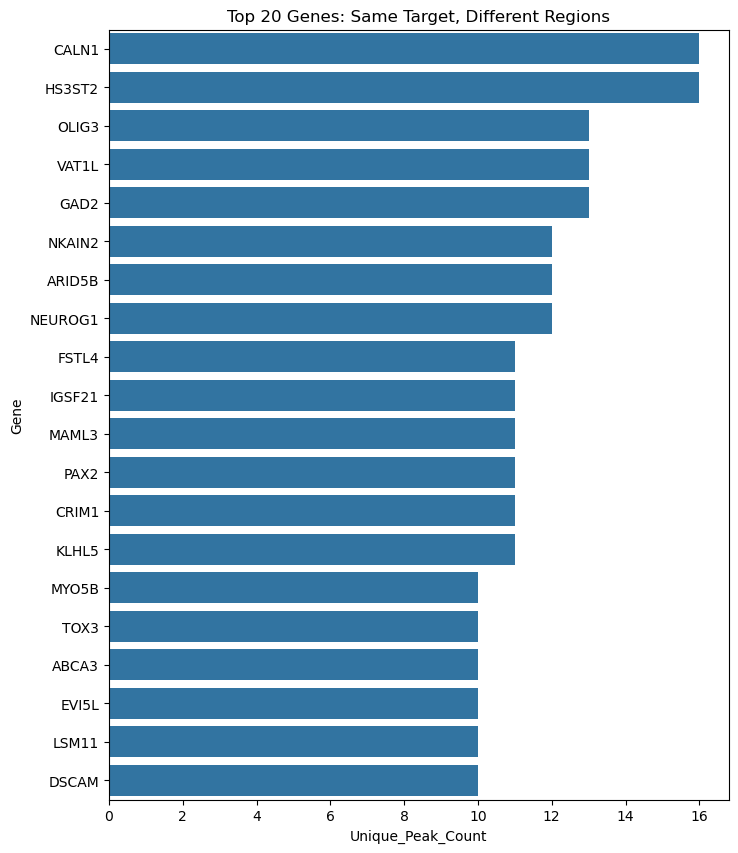

In [5]:
# 1. 获取两个谱系共有的基因 (Target)
shared_targets = set(ExN_links['target']).intersection(set(InN_links['target']))

# 2. 找出那些属于 Unique Link 的数据
# 即在 ExN 中有但在 InN 中没有的 link，或者反之
exn_unique_links = ExN_links[~ExN_links['link_id'].isin(set(InN_links['link_id']))]
inn_unique_links = InN_links[~InN_links['link_id'].isin(set(ExN_links['link_id']))]

# 3. 筛选出：这些 Unique Link 中，Target 必须是“共有基因”
# 这就是你要的 "Same Target, Diff Region"
st_dr_links = pd.concat([
    exn_unique_links[exn_unique_links['target'].isin(shared_targets)],
    inn_unique_links[inn_unique_links['target'].isin(shared_targets)]
])

# 4. 统计基因出现次数并排序
st_dr_counts = st_dr_links['target'].value_counts().reset_index()
st_dr_counts.columns = ['Gene', 'Unique_Peak_Count']

# 查看结果
print(st_dr_counts.head(20))

# 可视化 Top 20
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
sns.barplot(data=st_dr_counts.head(20), x='Unique_Peak_Count', y='Gene')
plt.title('Top 20 Genes: Same Target, Different Regions')
plt.show()

In [23]:
st_dr_counts[0:10]

,Gene,Unique_Peak_Count
0,CALN1,16
1,HS3ST2,16
2,OLIG3,13
3,VAT1L,13
4,GAD2,13
5,NKAIN2,12
6,ARID5B,12
7,NEUROG1,12
8,FSTL4,11
9,IGSF21,11


## part 2 in oligo

In [6]:
import pandas as pd

# 1. 加载数据
ExN_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_ExN.csv')
InN_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_InN.csv')
Oligo_links = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Neuron/outs/peak_gene_links_Oligo.csv')

# 2. 构造唯一标识符 (Target-Region)
ExN_links['link_id'] = ExN_links['target'] + "_" + ExN_links['region']
InN_links['link_id'] = InN_links['target'] + "_" + InN_links['region']
Oligo_links['link_id'] = Oligo_links['target'] + "_" + Oligo_links['region']

# 3. 提取神经元谱系的交集 (核心神经连接)
# 只有在 ExN 和 InN 中都完全一致的 link 才会保留
set_exn = set(ExN_links['link_id'])
set_inn = set(InN_links['link_id'])
shared_neural_ids = set_exn.intersection(set_inn)

# 获取核心神经连接的 DataFrame
neural_core = ExN_links[ExN_links['link_id'].isin(shared_neural_ids)].copy()

In [7]:
neural_core

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr,link_id
2,THOC1,chr18:305011-305512,0.091673,0.050323,0.004613,0.004613,[37212],37212,0.755463,THOC1_chr18:305011-305512
3,ARHGAP11A,chr15:32730626-32731127,0.027555,0.075908,0.002092,0.002092,[-90935],90935,0.897311,ARHGAP11A_chr15:32730626-32731127
4,KNOP1,chr16:19745203-19745704,0.039257,0.100808,0.003957,0.003957,[27219],27219,0.923684,KNOP1_chr16:19745203-19745704
5,KNOP1,chr16:19861874-19862375,0.093346,0.122009,0.011389,0.011389,[143889],143889,0.911618,KNOP1_chr16:19861874-19862375
9,THOC1,chr18:394833-395334,0.074530,0.042165,0.003143,0.003143,[127034],127034,0.577349,THOC1_chr18:394833-395334
...,...,...,...,...,...,...,...,...,...,...
28857,ZSCAN9,chr6:28252068-28252569,0.047892,0.051836,0.002483,0.002483,[-18831],18831,0.726207,ZSCAN9_chr6:28252068-28252569
28858,ZSCAN9,chr6:28335907-28336408,0.068243,0.054500,0.003719,0.003719,[-102671],102671,0.575485,ZSCAN9_chr6:28335907-28336408
28860,ABCA3,chr16:2236384-2236885,0.027108,0.081814,0.002218,0.002218,[-39247],39247,0.893244,ABCA3_chr16:2236384-2236885
28861,ZSCAN9,chr6:28081216-28081717,0.069319,0.069785,0.004837,0.004837,[143420],143420,0.833092,ZSCAN9_chr6:28081216-28081717


In [8]:
Oligo_links

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr,link_id
0,PHF21A,chr11:45993385-45993886,0.072395,0.064390,0.004662,0.004662,[0],0,0.609821,PHF21A_chr11:45993385-45993886
1,PHF21B,chr22:44797353-44797854,0.061779,0.071811,0.004436,0.004436,[-83558],83558,0.732959,PHF21B_chr22:44797353-44797854
2,PHF21B,chr22:44776581-44777082,0.045498,0.141630,0.006444,0.006444,[-104330],104330,0.718799,PHF21B_chr22:44776581-44777082
3,PHF21B,chr22:45077802-45078303,0.061203,0.101765,0.006228,0.006228,[68047],68047,0.838993,PHF21B_chr22:45077802-45078303
4,PHF21B,chr22:44994821-44995322,0.043875,0.112965,0.004956,0.004956,[0],0,0.629555,PHF21B_chr22:44994821-44995322
...,...,...,...,...,...,...,...,...,...,...
25134,GMIP,chr19:19642691-19643192,0.089979,0.102646,0.009236,0.009236,[0],0,0.667307,GMIP_chr19:19642691-19643192
25135,OTOGL,chr12:80052915-80053416,0.037886,0.047816,0.001812,0.001812,[46371],46371,0.588496,OTOGL_chr12:80052915-80053416
25136,OTOGL,chr12:80064078-80064579,0.146039,0.059182,0.008643,0.008643,[35209],35209,0.616124,OTOGL_chr12:80064078-80064579
25137,SYBU,chr8:109644560-109645061,0.045350,0.082769,0.003754,0.003754,[0],0,0.932858,SYBU_chr8:109644560-109645061


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

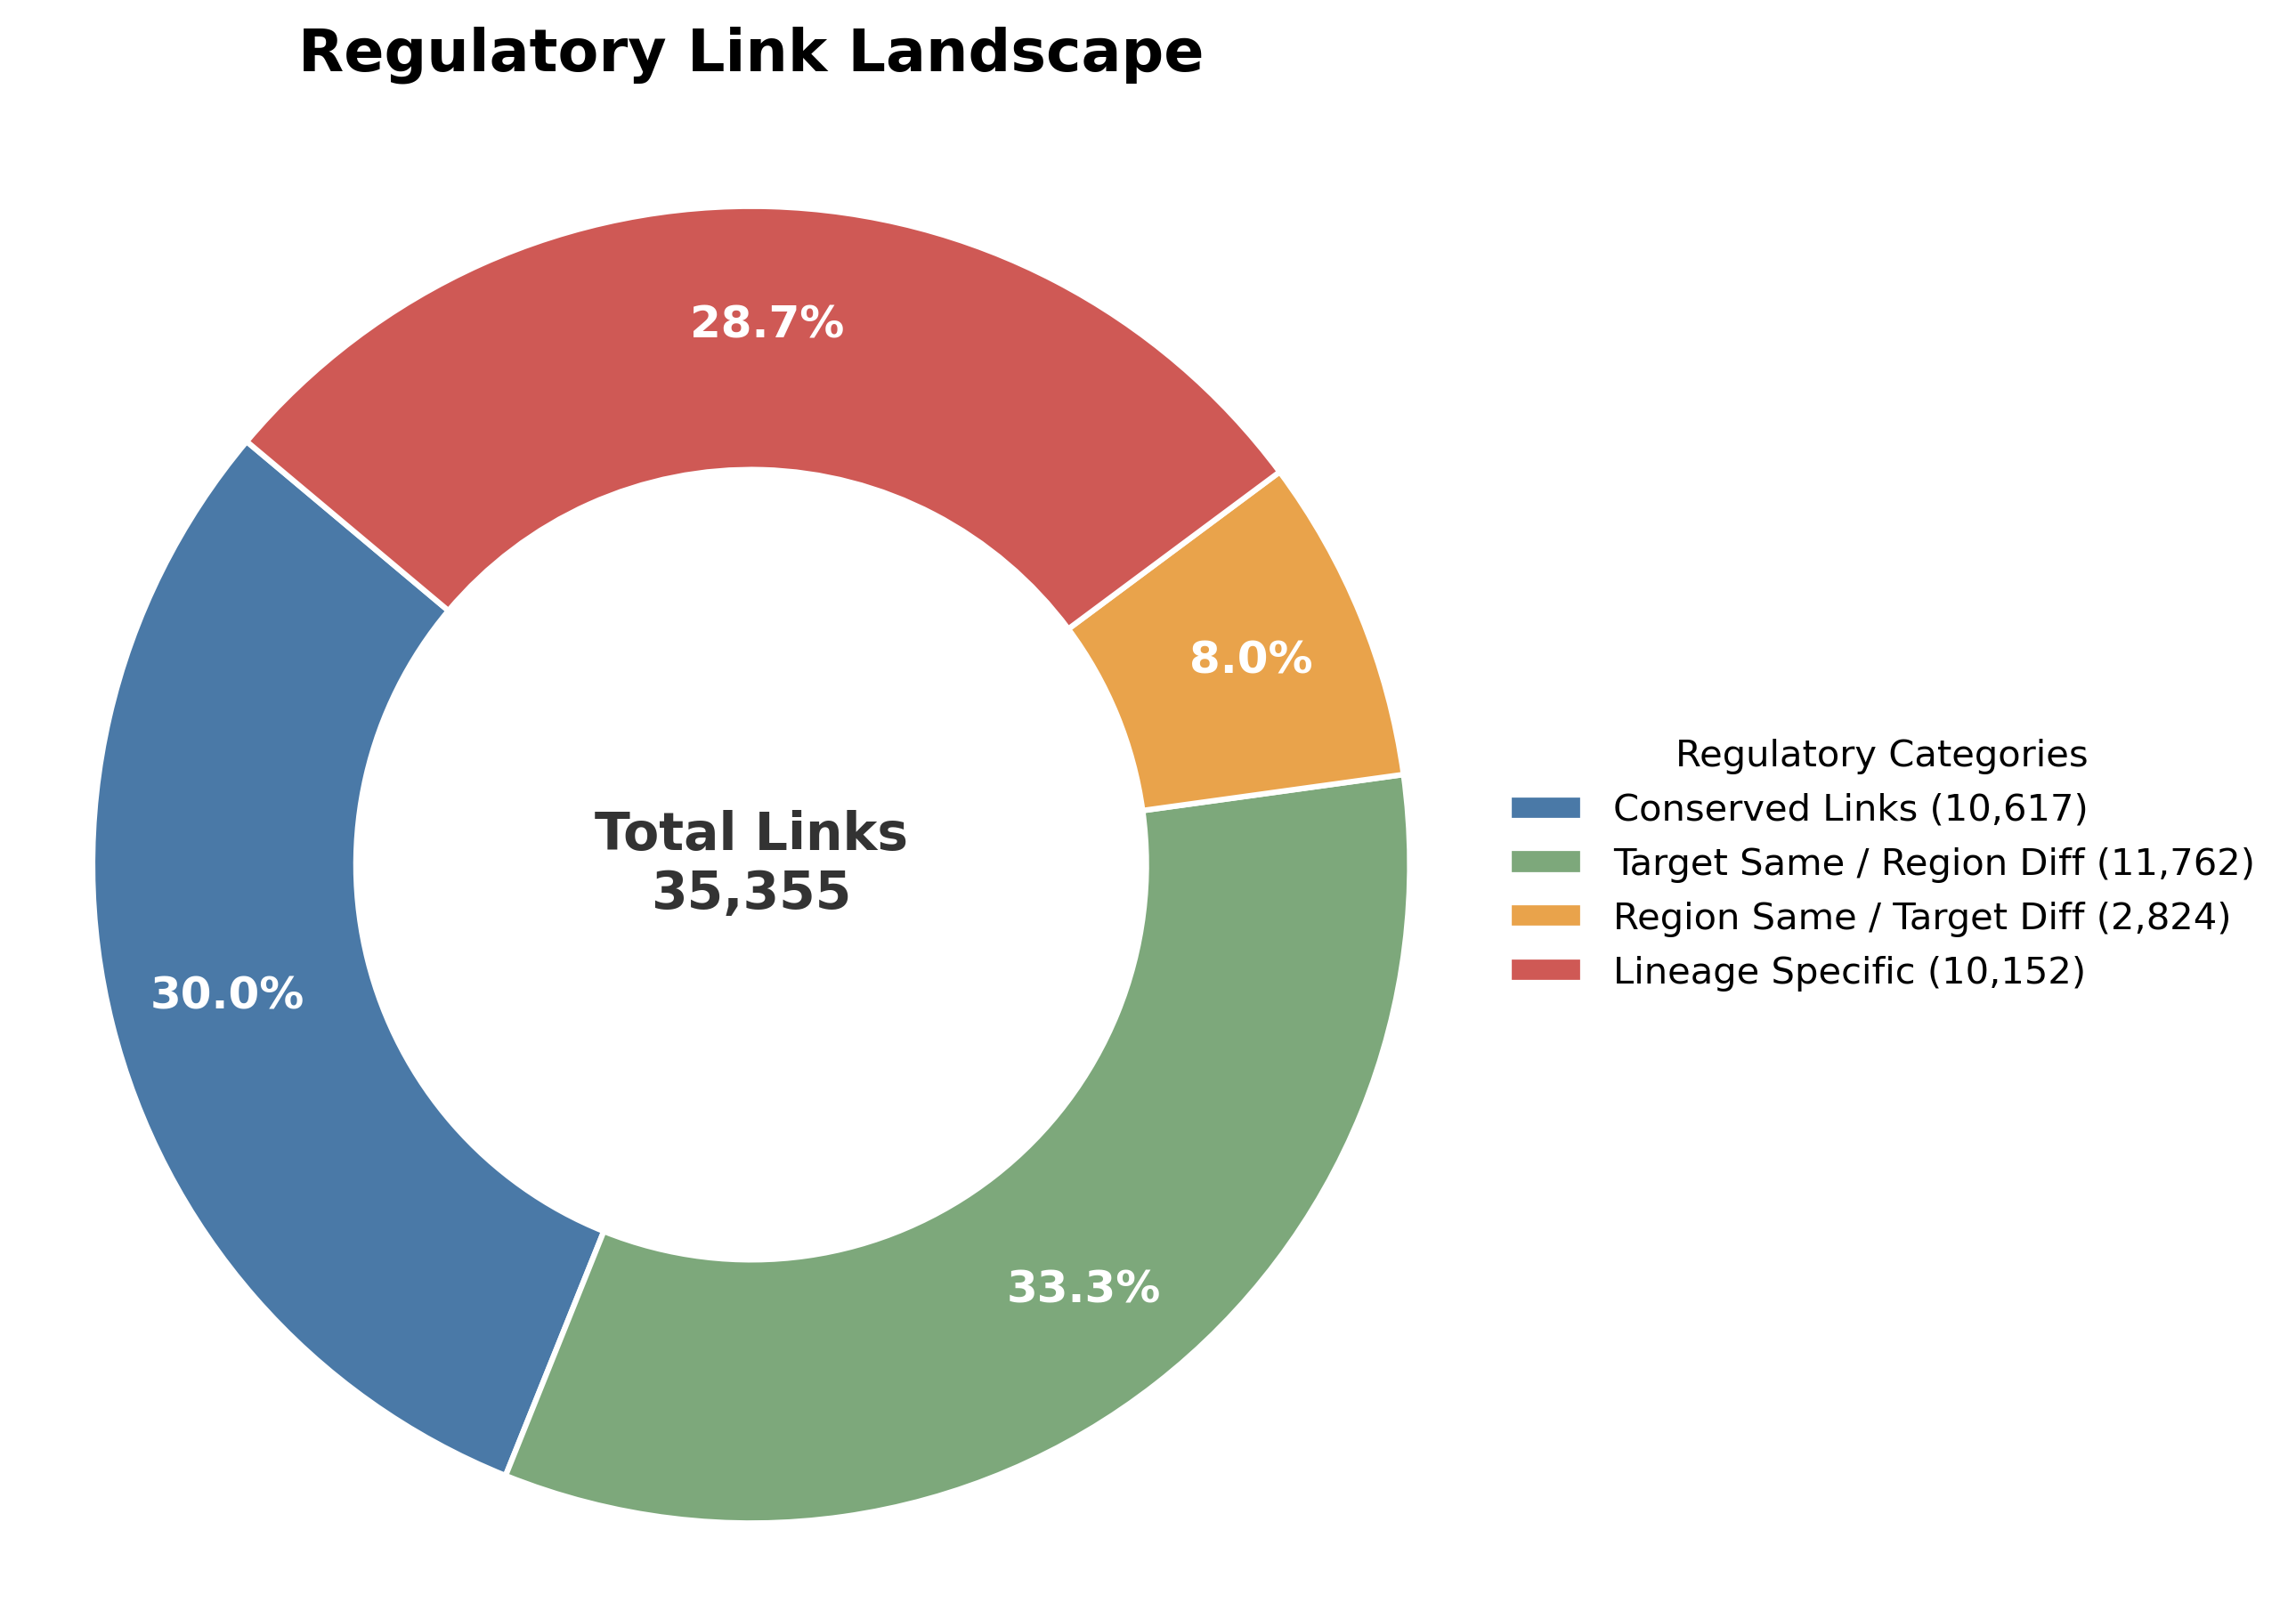

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 提取核心集合
# 获取两边所有的 link_id, target 和 region
set_neural_links = set(neural_core['link_id'])
set_oligo_links = set(Oligo_links['link_id'])

set_neural_targets = set(neural_core['target'])
set_oligo_targets = set(Oligo_links['target'])

set_neural_regions = set(neural_core['region'])
set_oligo_regions = set(Oligo_links['region'])

# 取所有连接的并集 (Union)
all_links = set_neural_links.union(set_oligo_links)

# 2. 分类统计
cat1_both_same = 0      # Target相同, Region相同 (Link完全一致)
cat2_target_same = 0    # Target相同, Region不同
cat3_region_same = 0    # Target不同, Region相同
cat4_both_diff = 0      # Target不同, Region不同 (完全特有)

for link in all_links:
    # 拆分 link_id 获取当前的 target 和 region
    # 注意：link_id 格式为 "Target_Region"
    target, region = link.split('_', 1)
    
    # 情况 1: 该连接在两边都存在
    if link in set_neural_links and link in set_oligo_links:
        cat1_both_same += 1
    else:
        # 该连接只存在于其中一边，我们去查它的组成部分在另一边是否存在
        # 判断 Target 是否在两边都出现过
        t_in_both = (target in set_neural_targets and target in set_oligo_targets)
        # 判断 Region 是否在两边都出现过
        r_in_both = (region in set_neural_regions and region in set_oligo_regions)
        
        if t_in_both and not r_in_both:
            cat2_target_same += 1
        elif r_in_both and not t_in_both:
            cat3_region_same += 1
        elif t_in_both and r_in_both:
            # Target 和 Region 都分别在两边出现过，但没组合成这个 link
            # 这种情况通常归为 "Target相同, Region不同" (代表同一个基因在不同谱系用了不同的Peak)
            cat2_target_same += 1
        else:
            cat4_both_diff += 1

import matplotlib.pyplot as plt
import matplotlib

# 【关键设置】为了能在 Adobe Illustrator 中编辑文字
matplotlib.rcParams['pdf.fonttype'] = 42
# 1. 准备数据 (请确保您的变量名一致)
labels = [
    'Conserved Links', 
    'Target Same / Region Diff', 
    'Region Same / Target Diff', 
    'Lineage Specific'
]
sizes = [cat1_both_same, cat2_target_same, cat3_region_same, cat4_both_diff]
total_links = sum(sizes)

# 2. 配色方案 (Nature 风格)
colors = ['#4A79A7', '#7DA87B', '#E9A34B', '#CF5955']

# 3. 创建画布
# 设置绘图背景为透明，方便 AI 抠图
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# 4. 绘制环形图
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.82, 
    # wedgeprops 设置边框细白线，width=0.3 决定环的粗细
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 1.5},
    # textprops 设置环内百分比字体
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}
)

# 5. 中心文字
ax.text(0, 0, f'Total Links\n{total_links:,}', 
        ha='center', va='center', 
        fontsize=14, fontweight='bold', 
        color='#333333')

# 6. 图例设置
# 将图例放在右侧，去掉边框
legend_labels = [f'{l} ({s:,})' for l, s in zip(labels, sizes)]
ax.legend(
    wedges, legend_labels,
    title="Regulatory Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10,
    frameon=False
)

# 7. 细节微调
ax.set_title('Regulatory Link Landscape', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal') 

# 8. 【核心步骤】保存为 PDF 和 SVG
# AI 完美支持 PDF 和 SVG 矢量格式
plt.savefig("./plot/Lineage_regulatory_links.pdf", format='pdf', bbox_inches='tight', transparent=True)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

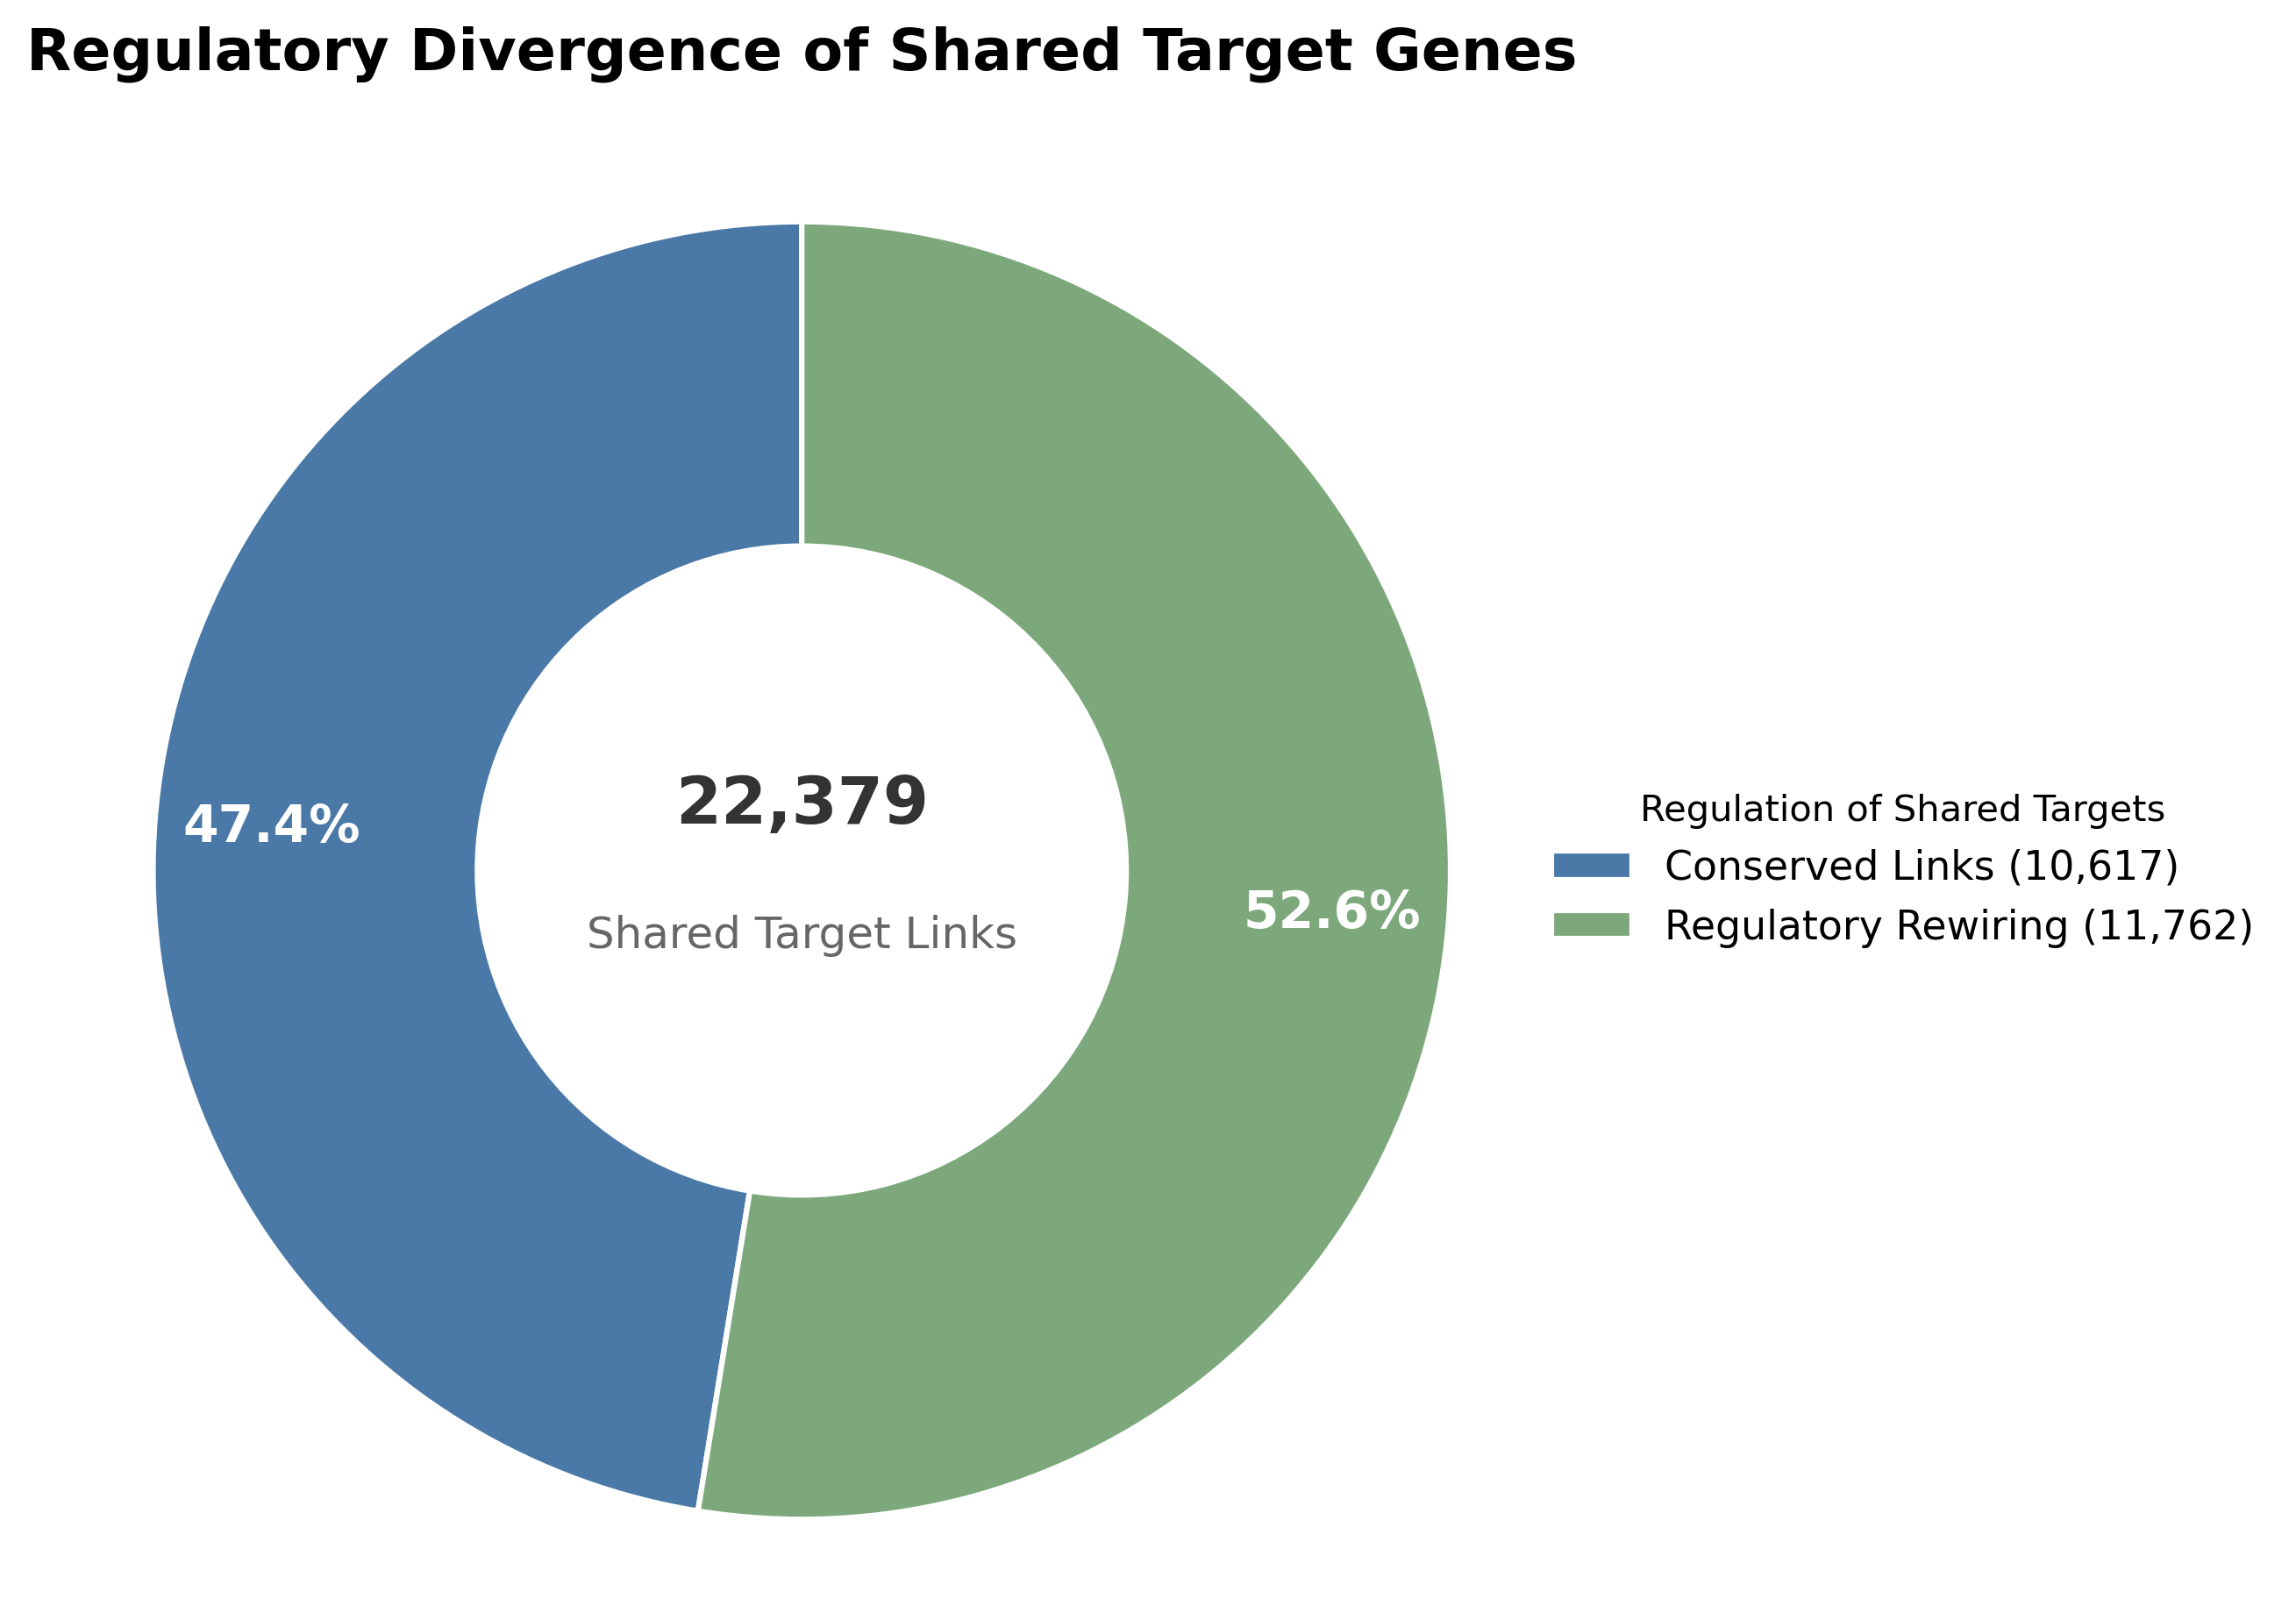

In [24]:
import matplotlib.pyplot as plt
import matplotlib

# 【关键设置】AI 可编辑
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# 1. 提取子集数据
# 只关注共有 Target 的两种 Link 模式
sub_labels = [
    'Conserved Mechanisms', 
    'Regulatory Rewiring'  # 这里将 Target Same / Region Diff 称为“调控重连”，更具学术感
]
sub_sizes = [cat1_both_same, cat2_target_same]
sub_total = sum(sub_sizes)

# 2. 配色方案 (保持与主图一致的 蓝色 和 绿色)
sub_colors = ['#4A79A7', '#7DA87B']

# 3. 创建画布
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# 4. 绘制环形图
wedges, texts, autotexts = ax.pie(
    sub_sizes, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sub_colors, 
    pctdistance=0.82, 
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'}
)

# 5. 中心文字 (突出显示这是共有靶基因的调控分布)
ax.text(0, 0.1, f'{sub_total:,}', 
        ha='center', va='center', 
        fontsize=18, fontweight='bold', color='#333333')
ax.text(0, -0.1, 'Shared Target Links', 
        ha='center', va='center', 
        fontsize=12, color='#666666')

# 6. 图例设置
# 标注清楚每一类的含义
legend_labels = [
    f'Conserved Links ({cat1_both_same:,})', 
    f'Regulatory Rewiring ({cat2_target_same:,})'
]
ax.legend(
    wedges, legend_labels,
    title="Regulation of Shared Targets",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    frameon=False
)

# 7. 标题 (侧重于描述共有基因的调控灵活性)
ax.set_title('Regulatory Divergence of Shared Target Genes', 
             fontsize=16, fontweight='bold', pad=25)

ax.axis('equal') 

# 8. 保存
plt.savefig("./plot/Shared_Targets_Regulatory_Divergence.pdf", format='pdf', bbox_inches='tight', transparent=True)

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif'

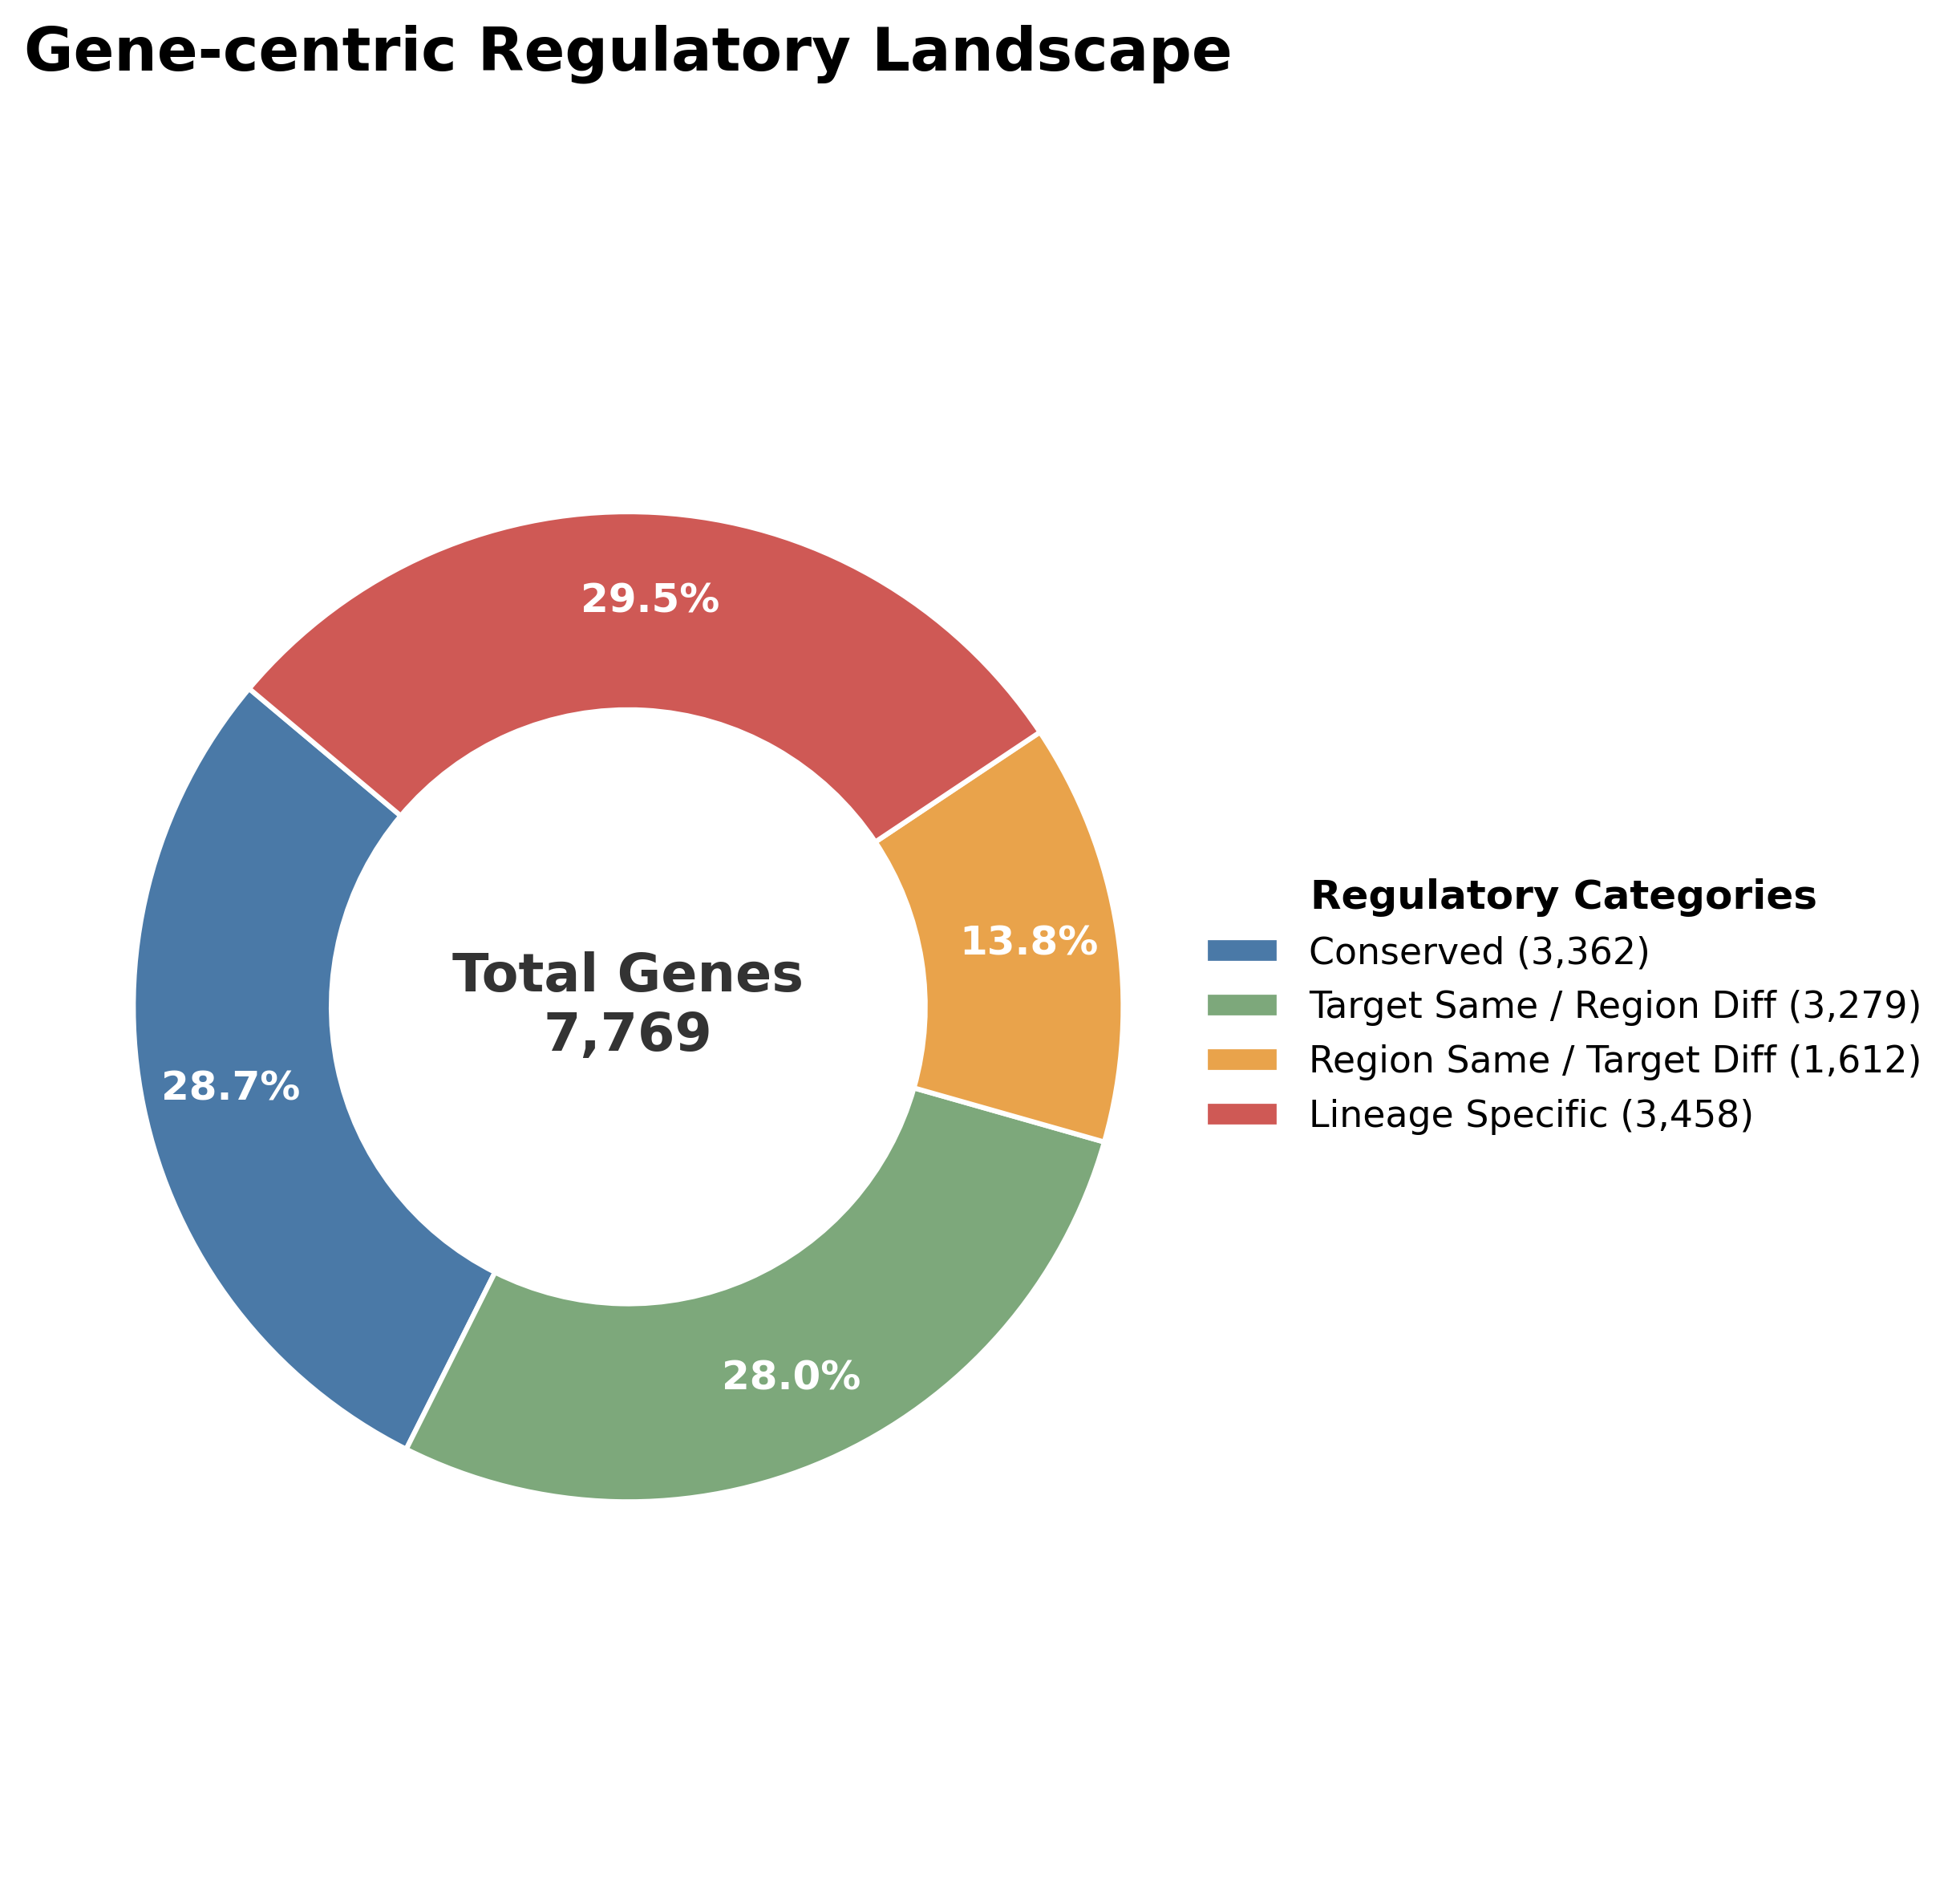

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 准备基础集合 (与之前一致)
set_neural_links = set(neural_core['link_id'])
set_oligo_links = set(Oligo_links['link_id'])

set_neural_targets = set(neural_core['target'])
set_oligo_targets = set(Oligo_links['target'])

set_neural_regions = set(neural_core['region'])
set_oligo_regions = set(Oligo_links['region'])

all_links = set_neural_links.union(set_oligo_links)

# 2. 初始化四个集合，用于存放每个分类中的唯一基因
genes_cat1 = set()  # Target & Region Same
genes_cat2 = set()  # Target Same, Region Diff
genes_cat3 = set()  # Region Same, Target Diff
genes_cat4 = set()  # Both Different

# 3. 遍历所有 Links 进行归类，并将基因加入对应的 Set
for link in all_links:
    target, region = link.split('_', 1)
    
    # 判断逻辑
    if link in set_neural_links and link in set_oligo_links:
        # 分类 1: 完美的共有连接
        genes_cat1.add(target)
    else:
        # 该连接只存在于其中一方
        t_in_both = (target in set_neural_targets and target in set_oligo_targets)
        r_in_both = (region in set_neural_regions and region in set_oligo_regions)
        
        if t_in_both:
            # 分类 2: 基因在两边都有，但这个具体的调控区域-基因组合是特有的
            genes_cat2.add(target)
        elif r_in_both:
            # 分类 3: 基因是特有的，但它用的 Region 在另一方也开放（调控了别的基因）
            genes_cat3.add(target)
        else:
            # 分类 4: 基因和区域在另一方都没出现过
            genes_cat4.add(target)
import pandas as pd
import matplotlib.pyplot as plt

# 1. 基础数据准备 (延续你的计算结果)
labels = [
    'Conserved', 
    'Target Same / Region Diff', 
    'Region Same / Target Diff', 
    'Lineage Specific'
]
counts = [len(genes_cat1), len(genes_cat2), len(genes_cat3), len(genes_cat4)]
total_genes = len(set_neural_targets | set_oligo_targets)

# 2. 配色方案 (Nature 风格常用的专业配色)
# 蓝色(保守), 绿色(重组), 橙色(重用), 红色(特异)
colors = ['#4A79A7', '#7DA87B', '#E9A34B', '#CF5955']

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(8, 8), dpi=300) # 高分辨率

# 绘制环形图
# wedgeprops={'width': 0.4} 制作环形效果，edgecolor='white' 增加分割白线
wedges, texts, autotexts = ax.pie(
    counts, 
    labels=None, # 先不放标签，后面通过 legend 处理
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.82, # 百分比标注的位置
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}
)

# 4. 中间添加总数文字
ax.text(0, 0, f'Total Genes\n{total_genes:,}', 
        ha='center', va='center', 
        fontsize=16, fontweight='bold', 
        fontfamily='Arial', color='#333333')

# 5. 美化标注 (添加外部图例)
# 创建带数值的标签
legend_labels = [f'{l} ({c:,})' for l, c in zip(labels, counts)]
legend = ax.legend(
    wedges, legend_labels,
    title="Regulatory Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # 将图例放在右侧
    fontsize=11,
    title_fontsize=12,
    frameon=False # 去掉图例边框
)
plt.setp(legend.get_title(), fontweight='bold')

# 7. 细节修饰
ax.set_title('Gene-centric Regulatory Landscape', 
             pad=20, fontsize=18, fontweight='bold', loc='center')

# 保持正圆
ax.axis('equal')  

plt.tight_layout()


plt.savefig("./plot/Lineage_regulatory_genes.pdf", bbox_inches='tight')

plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

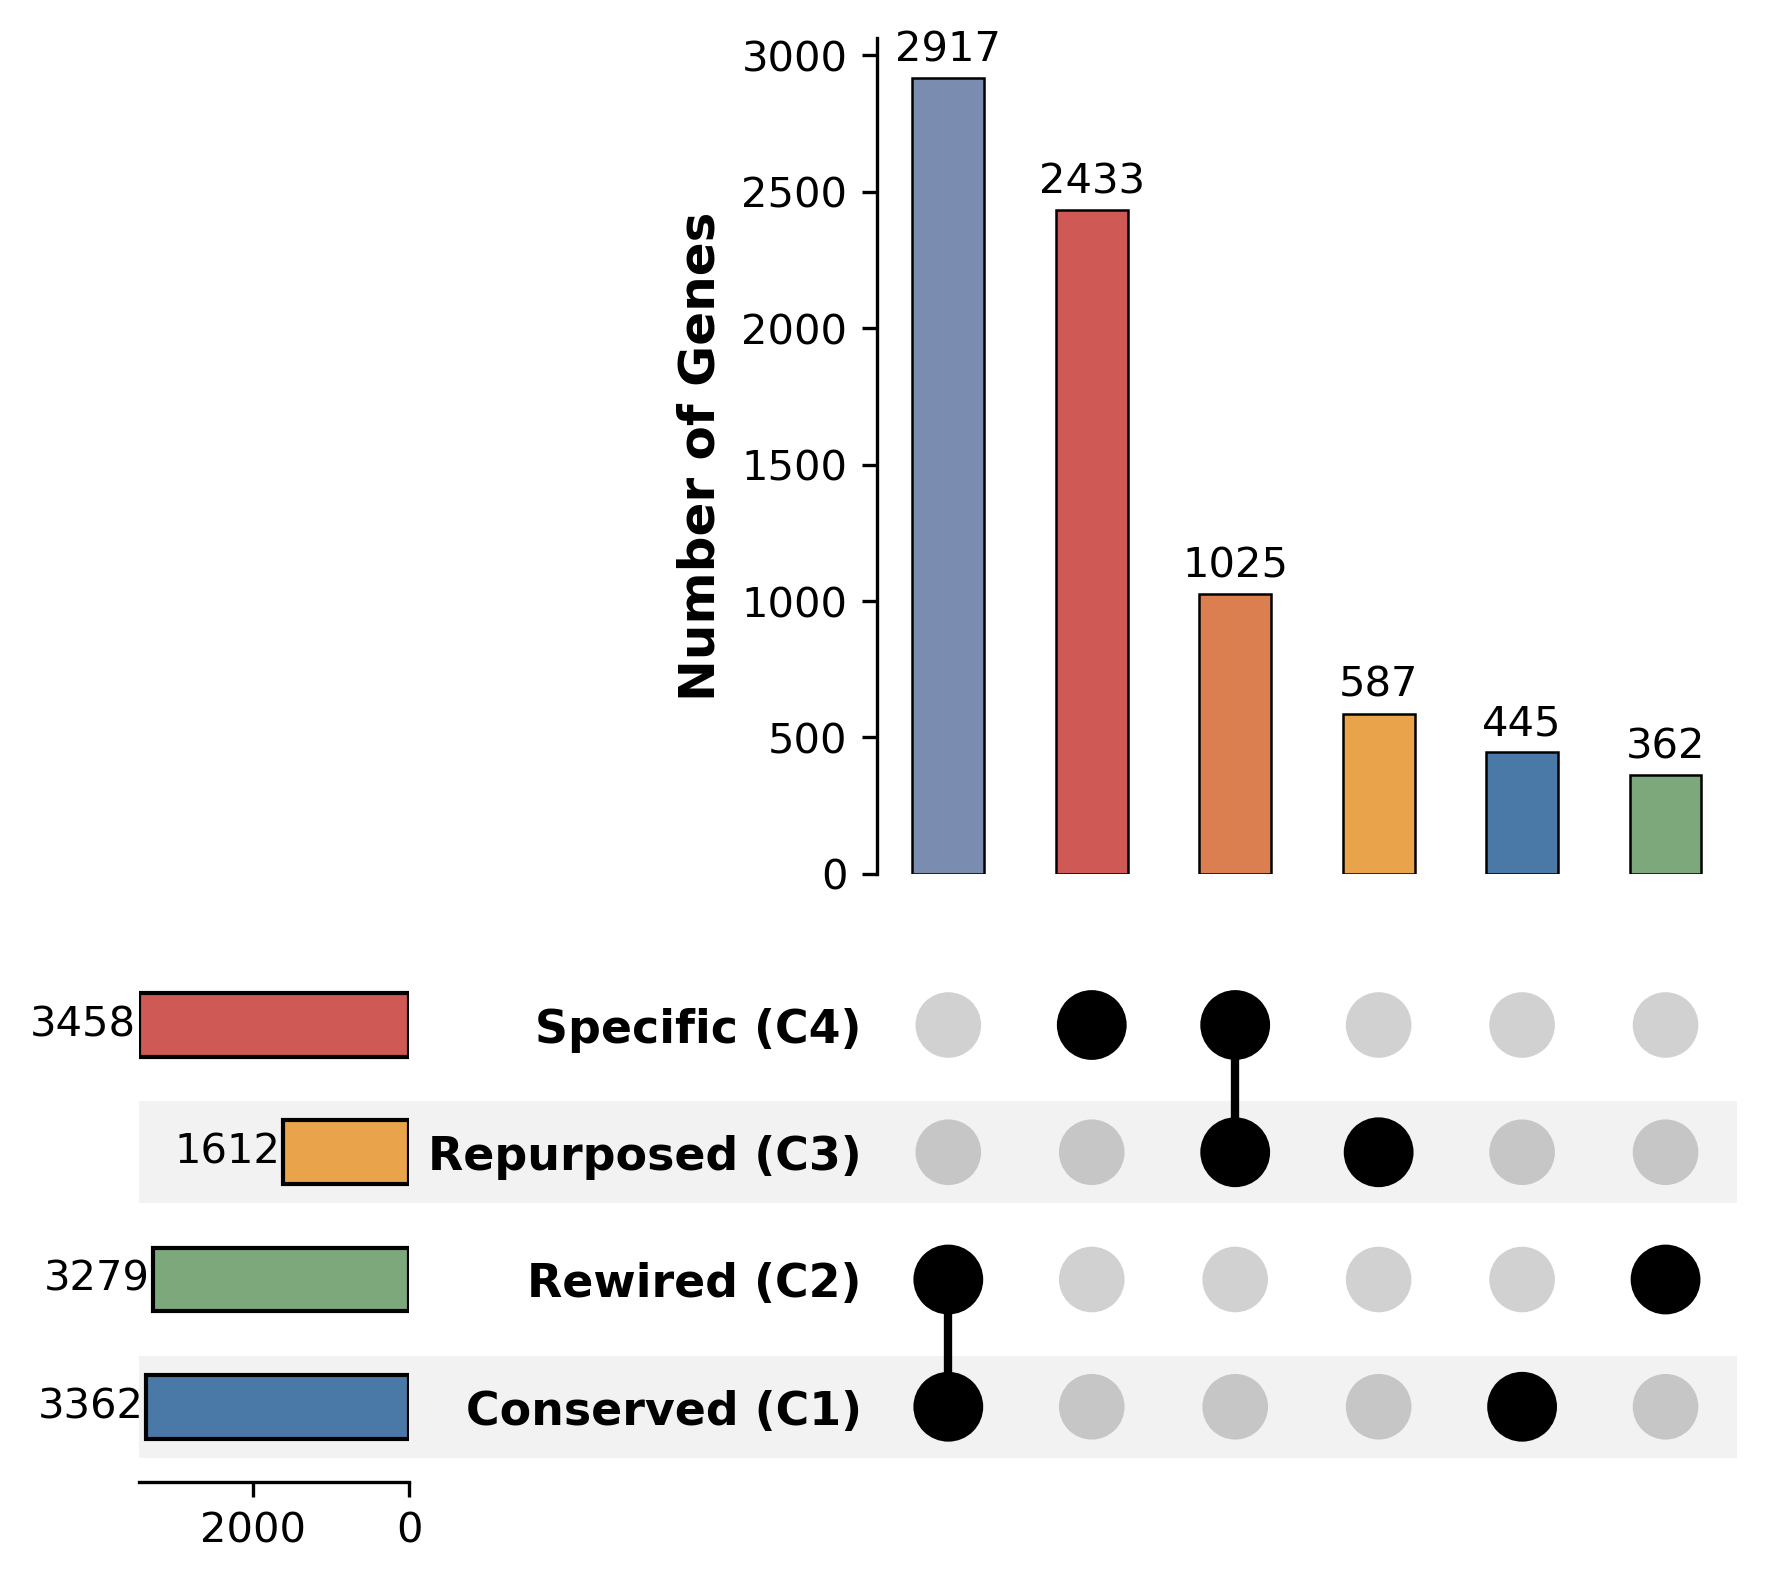

In [39]:
import pandas as pd
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt
import matplotlib

# 【关键设置】AI 可编辑 & Nature 指定字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# 1. 严格按顺序准备数据 (C1 -> C4)
# 这样在矩阵中，C1 会在最上方，C4 在最下方
contents = {
    'Conserved (C1)': list(genes_cat1),
    'Rewired (C2)': list(genes_cat2),
    'Repurposed (C3)': list(genes_cat3),
    'Specific (C4)': list(genes_cat4)
}

# 转换数据格式
data = from_contents(contents)

# 定义标准的分类颜色映射
category_color_dict = {
    'Conserved (C1)': '#4A79A7', # 蓝色
    'Rewired (C2)': '#7DA87B',   # 绿色
    'Repurposed (C3)': '#E9A34B', # 橙色
    'Specific (C4)': '#CF5955'    # 红色
}

# 2. 创建 UpSet 对象
upset = UpSet(data, 
              subset_size='count',
              show_counts='{:d}',
              sort_by='cardinality', 
              sort_categories_by=None, # 关键：保持 C1-C4 的输入顺序
              orientation='horizontal',
              shading_color=0.05,    
              with_lines=True,       
              element_size=45        
             )

# 3. 绘图
fig = plt.figure(figsize=(12, 8), dpi=300)
dict_ax = upset.plot(fig)

# 4. 获取各个子图 Axes
ax_inter = dict_ax['intersections']
ax_matrix = dict_ax['matrix']
ax_totals = dict_ax['totals']

# --- A. 柱状图配色 (基于交集身份手动校准) ---
# 顺序基于数据大小：2917(C1&C2), 2433(C4), 1025(C3&C4), 587(C3), 445(C1), 362(C2)
# 我们使用混合色来表示交集
colors_inter = [
    '#7A8DB1', # 2917 (C1 & C2) - 混合蓝绿
    '#CF5955', # 2433 (C4 only) - 红色
    '#DB7E50', # 1025 (C3 & C4) - 混合橙红
    '#E9A34B', # 587  (C3 only) - 橙色
    '#4A79A7', # 445  (C1 only) - 蓝色
    '#7DA87B'  # 362  (C2 only) - 绿色
]

for bar, col in zip(ax_inter.patches, colors_inter):
    bar.set_facecolor(col)
    bar.set_edgecolor('black')
    bar.set_linewidth(0.6)

ax_inter.grid(False)
ax_inter.spines['top'].set_visible(False)
ax_inter.spines['right'].set_visible(False)
ax_inter.set_ylabel('Number of Genes', fontsize=12, fontweight='bold')

# --- B. 左侧条形图配色 (核心修正点) ---
ax_totals.grid(False)
ax_totals.spines['top'].set_visible(False)
ax_totals.spines['left'].set_visible(False)

# 动态获取 totals 里的分类名称，并根据字典匹配颜色
# upset.totals.index 的顺序是从下往上的 [C4, C3, C2, C1] 或者相反
# 我们直接遍历当前 axis 中的 label 来赋色
current_categories = upset.totals.index.tolist()
for i, cat_name in enumerate(current_categories):
    # 根据分类名称在字典中找颜色
    col = category_color_dict.get(cat_name, '#555555')
    # i 对应 ax_totals.patches 的索引
    ax_totals.patches[i].set_facecolor(col)
    ax_totals.patches[i].set_height(0.5)

# --- C. 点阵图美化 ---
ax_matrix.grid(False)
ax_matrix.set_yticklabels(ax_matrix.get_yticklabels(), fontsize=11, fontweight='bold')

# 5. 保存 PDF (AI 完美编辑)
plt.savefig("./plot/UpSet_Gene_Landscape.pdf", format='pdf', bbox_inches='tight', transparent=True)
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

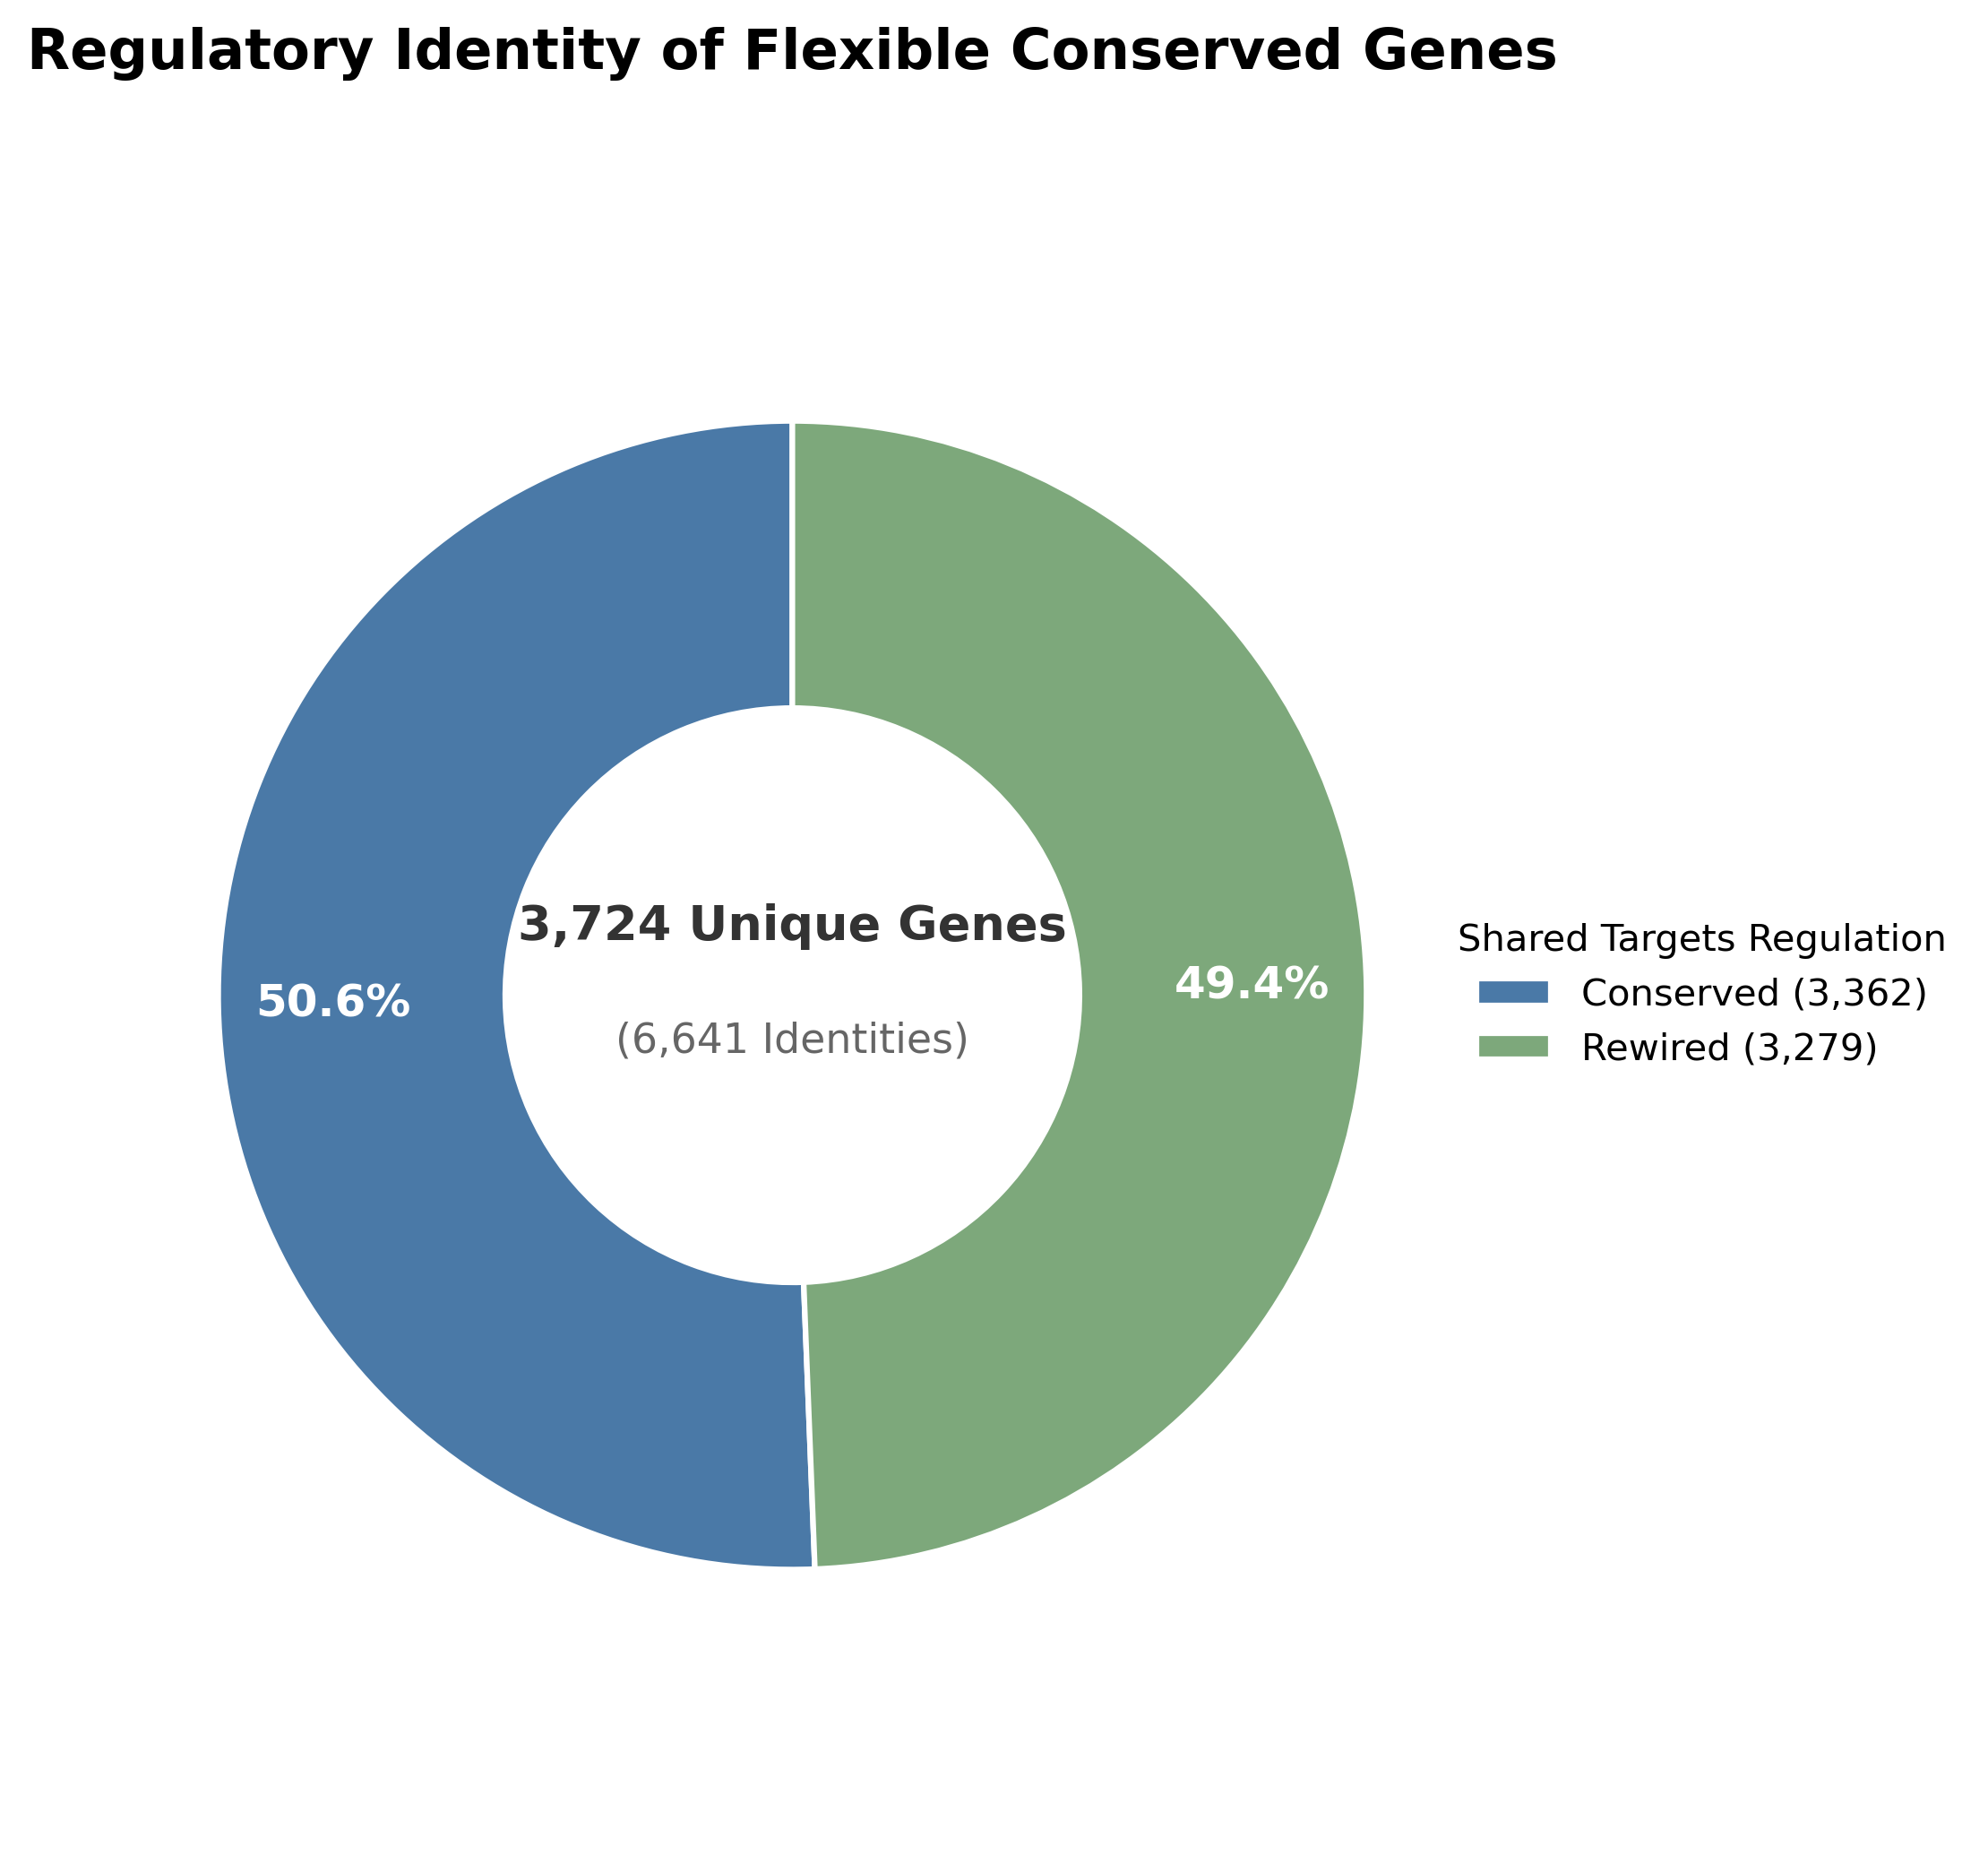

In [23]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# 【关键设置】确保 Adobe Illustrator 中文字可编辑
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# 1. 计算子集数据
# 我们关注的是 Shared Targets 阵营，即涉及到 Cat1 或 Cat2 的基因
# 计算该阵营内两种调控身份的赋值次数
sub_labels = ['Conserved Identity', 'Rewired Identity']
sub_counts = [len(genes_cat1), len(genes_cat2)]
sub_assignments = sum(sub_counts)

# 计算该阵营中去重后的唯一基因数 (即你之前发现的 2917 个双重身份基因 + 只属于其中一类的基因)
shared_target_genes_unique = len(genes_cat1 | genes_cat2)

gene_counts = [len(genes_cat1), len(genes_cat2)] # 3362, 3279
sub_assignments = sum(gene_counts) # 6641

# 2. 配色方案 (保持与主图一致的 蓝色 和 绿色)
sub_colors = ['#4A79A7', '#7DA87B']

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

# 4. 绘制环形图
wedges, texts, autotexts = ax.pie(
    gene_counts, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=sub_colors, 
    pctdistance=0.8, 
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}
)

# 5. 中心文字 (体现基因数和身份赋值数)
ax.text(0, 0.12, f'{shared_target_genes_unique:,} Unique Genes', 
        ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#333333')

ax.text(0, -0.08, f'({sub_assignments:,} Identities)', 
        ha='center', va='center', 
        fontsize=11, color='#666666')

# 6. 图例设置
legend_labels = [
    f'Conserved ({len(genes_cat1):,})', 
    f'Rewired ({len(genes_cat2):,})'
]
ax.legend(
    wedges, legend_labels,
    title="Shared Targets Regulation",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10,
    frameon=False
)

# 7. 细节修饰
ax.set_title('Regulatory Identity of Flexible Conserved Genes', 
             fontsize=15, fontweight='bold', pad=25)

ax.axis('equal') 
plt.tight_layout()

# 8. 保存 PDF
plt.savefig("./plot/Shared_Genes_Regulatory_Divergence.pdf", format='pdf', bbox_inches='tight', transparent=True)

plt.show()

In [ ]:
import pandas as pd
from upsetplot import from_contents, plot
import matplotlib.pyplot as plt
import matplotlib

# 【关键设置】确保 Adobe Illustrator 文字可编辑
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial']

# 1. 准备数据
contents = {
    'Conserved Target': list(genes_cat1),
    'Rewired Target': list(genes_cat2)
}

# 转换数据格式
data = from_contents(contents)

# 2. 创建画布
fig = plt.figure(figsize=(10, 7), dpi=300)

# 3. 使用 upsetplot 绘制
# 将 show_counts 设置为 True 或 '{:d}' 以修复 KeyError
upset = plot(data, fig=fig, element_size=None, 
             facecolor="#4A79A7", 
             shading_color=0.1, 
             show_counts=True,  # <--- 修复点：直接用 True，库会自动处理数字
             sort_by='cardinality', 
             sort_categories_by=None)

# 4. 精细化美化颜色
# 注意：upsetplot 返回的是一个包含多个 axes 的字典
ax_inter = upset['intersections']

# 获取柱子并设置颜色
# 排序后顺序通常是：Dual (2917), Conserved (445), Rewired (362)
# 如果你的数据量很大，可能需要动态判断颜色，这里我们直接根据数量级设置
patches = ax_inter.patches
if len(patches) >= 3:
    patches[0].set_facecolor('#9182C4') # 交集 (最大) 用紫色
    patches[1].set_facecolor('#4A79A7') # 蓝色
    patches[2].set_facecolor('#7DA87B') # 绿色

# 5. 修改标签
ax_inter.set_ylabel('Number of Genes', fontsize=12, fontweight='bold')
upset['totals'].set_xlabel('Total Set Size', fontsize=12, fontweight='bold')

# 添加主标题
plt.suptitle('Regulatory Complexity of Shared Target Genes', 
             fontsize=16, fontweight='bold', y=0.98)

# 6. 保存 PDF
plt.savefig("./plot/Shared_Genes_UpSet.pdf", format='pdf', bbox_inches='tight', transparent=True)

plt.show()

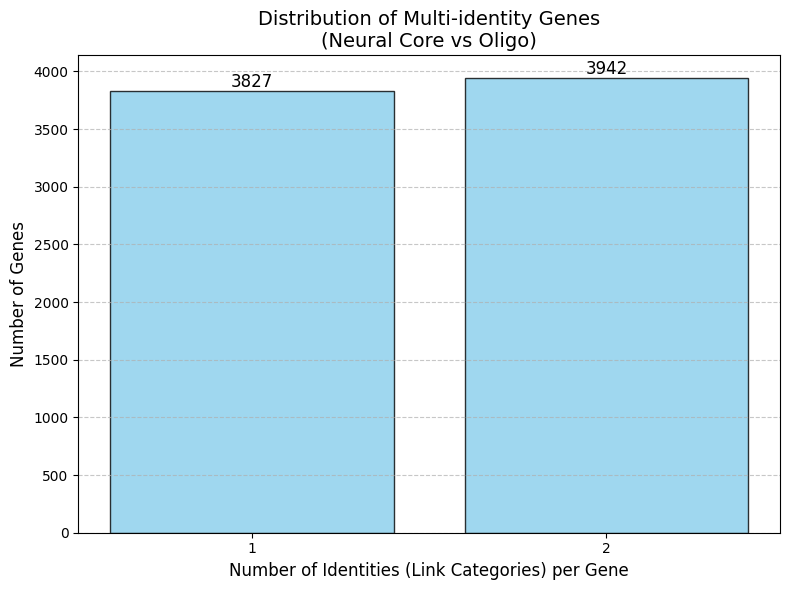

共有 0 个基因同时拥有全部 4 种调控身份。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. 延续之前的集合定义 (确保 genes_cat1 到 cat4 已经生成)
# 这里的 genes_cat1, genes_cat2, genes_cat3, genes_cat4 分别是四个分类的基因集合(set)

# 2. 计算每个基因拥有的身份数量
all_unique_genes = genes_cat1 | genes_cat2 | genes_cat3 | genes_cat4

gene_identity_counts = {}

for gene in all_unique_genes:
    count = 0
    if gene in genes_cat1: count += 1
    if gene in genes_cat2: count += 1
    if gene in genes_cat3: count += 1
    if gene in genes_cat4: count += 1
    gene_identity_counts[gene] = count

# 3. 统计“拥有n个身份”的基因数量
# 结果类似 {1: 5000, 2: 1200, 3: 300, 4: 50}
final_stats = Counter(gene_identity_counts.values())

# 排序以确保柱状图 x 轴按 1, 2, 3, 4 排列
x_labels = sorted(final_stats.keys())
y_values = [final_stats[x] for x in x_labels]

# 4. 绘制柱状图
plt.figure(figsize=(8, 6))
bars = plt.bar(x_labels, y_values, color='#87CEEB', edgecolor='black', alpha=0.8)

# 在柱子上添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Number of Identities (Link Categories) per Gene', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.title('Distribution of Multi-identity Genes\n(Neural Core vs Oligo)', fontsize=14)
plt.xticks(x_labels) # 确保只显示 1, 2, 3, 4
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

共有 3942 个基因具有双重身份。

身份组合分布：
(Cat1: Same T, Same R, Cat2: Same T, Diff R)    2917
(Cat3: Diff T, Same R, Cat4: Both Diff)         1025
dtype: int64


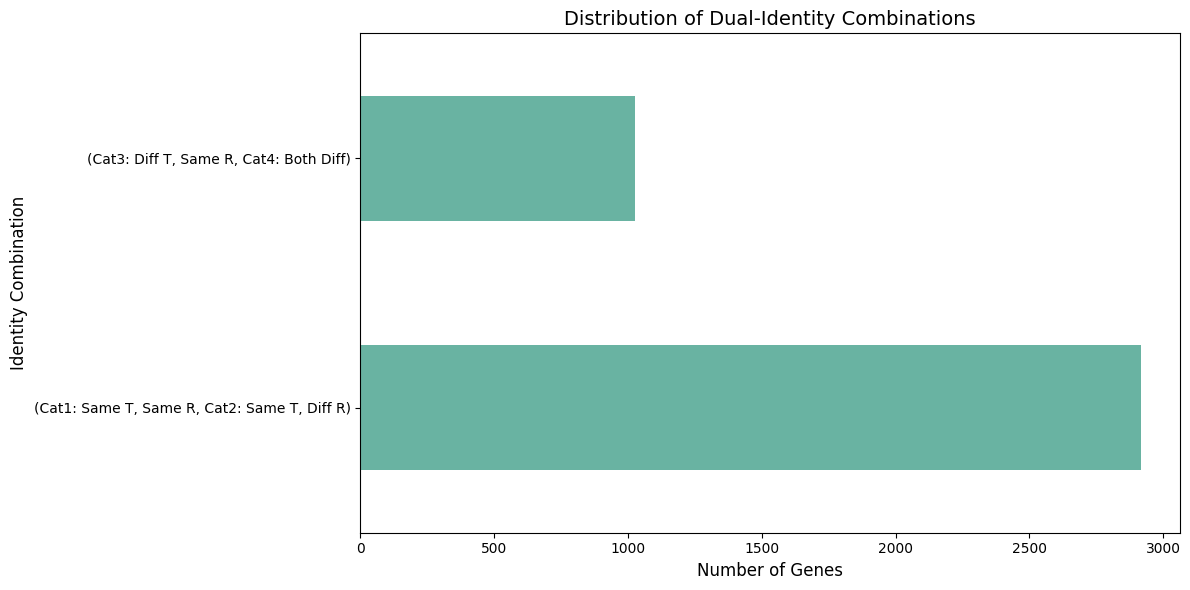


前 20 个双重身份基因示例：
       Gene                                  Combination
0     FBXO5  Cat1: Same T, Same R & Cat2: Same T, Diff R
1     TMCC3  Cat1: Same T, Same R & Cat2: Same T, Diff R
2    CTNNA1  Cat1: Same T, Same R & Cat2: Same T, Diff R
3     FANCC  Cat1: Same T, Same R & Cat2: Same T, Diff R
4      GNB4  Cat1: Same T, Same R & Cat2: Same T, Diff R
5    SPTAN1       Cat3: Diff T, Same R & Cat4: Both Diff
6   ATF7IP2       Cat3: Diff T, Same R & Cat4: Both Diff
7    KRBOX4  Cat1: Same T, Same R & Cat2: Same T, Diff R
8     MORC4  Cat1: Same T, Same R & Cat2: Same T, Diff R
9     HOXA9       Cat3: Diff T, Same R & Cat4: Both Diff
10  SLC13A3       Cat3: Diff T, Same R & Cat4: Both Diff
11    FANCB  Cat1: Same T, Same R & Cat2: Same T, Diff R
12    TMCO4  Cat1: Same T, Same R & Cat2: Same T, Diff R
13   YTHDF3       Cat3: Diff T, Same R & Cat4: Both Diff
14    GPR19       Cat3: Diff T, Same R & Cat4: Both Diff
15   PKMYT1  Cat1: Same T, Same R & Cat2: Same T, Diff R
16     MCL1   

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 建立基因到身份的映射
# 假设 genes_cat1, genes_cat2, genes_cat3, genes_cat4 已经是前面代码生成的集合
gene_to_identities = {}
all_genes = genes_cat1 | genes_cat2 | genes_cat3 | genes_cat4

for gene in all_genes:
    ids = []
    if gene in genes_cat1: ids.append("Cat1: Same T, Same R")
    if gene in genes_cat2: ids.append("Cat2: Same T, Diff R")
    if gene in genes_cat3: ids.append("Cat3: Diff T, Same R")
    if gene in genes_cat4: ids.append("Cat4: Both Diff")
    gene_to_identities[gene] = sorted(ids)

# 2. 筛选出具有 2 个身份的基因
dual_identity_genes = {g: tuple(ids) for g, ids in gene_to_identities.items() if len(ids) == 2}

# 3. 统计身份组合的分布
combination_counts = pd.Series(dual_identity_genes.values()).value_counts()

# 4. 打印统计结果
print(f"共有 {len(dual_identity_genes)} 个基因具有双重身份。")
print("\n身份组合分布：")
print(combination_counts)

# 5. 可视化身份组合
plt.figure(figsize=(12, 6))
combination_counts.plot(kind='barh', color='#69b3a2')
plt.title('Distribution of Dual-Identity Combinations', fontsize=14)
plt.xlabel('Number of Genes', fontsize=12)
plt.ylabel('Identity Combination', fontsize=12)
plt.tight_layout()
plt.show()

# 6. 输出具体的基因列表（以 DataFrame 形式查看）
df_dual = pd.DataFrame([
    {'Gene': g, 'Combination': " & ".join(ids)} 
    for g, ids in dual_identity_genes.items()
])

# 导出或查看前 20 个
print("\n前 20 个双重身份基因示例：")
print(df_dual.head(20))

# 如果想保存这些基因列表：
# df_dual.to_csv('dual_identity_genes.csv', index=False)

In [45]:
import pandas as pd

# 1. 从两个数据框中提取 NEK7 的数据
nek7_neural = neural_core[neural_core['target'] == 'ETV6'].copy()
nek7_oligo = Oligo_links[Oligo_links['target'] == 'ETV6'].copy()

# 2. 标记来源
nek7_neural['Lineage'] = 'Neural_Core'
nek7_oligo['Lineage'] = 'Oligo'

# 3. 合并查看对比
# 我们可以通过 region 来对比，看哪些 Peak 是共有的
nek7_combined = pd.concat([nek7_neural, nek7_oligo], axis=0).sort_values(by=['region', 'Lineage'])

# 4. 找出共有的 Link (Conserved) 和 特有的 Link (Rewired)
shared_regions = set(nek7_neural['region']).intersection(set(nek7_oligo['region']))
neural_only_regions = set(nek7_neural['region']) - set(nek7_oligo['region'])
oligo_only_regions = set(nek7_oligo['region']) - set(nek7_neural['region'])

In [46]:
nek7_neural

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr,link_id,Lineage
16231,ETV6,chr12:11838882-11839383,0.023002,0.066032,0.001519,0.001519,[0],0,0.681500,ETV6_chr12:11838882-11839383,Neural_Core
16232,ETV6,chr12:11813323-11813824,0.038231,0.112494,0.004301,0.004301,[0],0,0.803118,ETV6_chr12:11813323-11813824,Neural_Core
16236,ETV6,chr12:11556146-11556647,0.073949,0.072857,0.005388,0.005388,[93278],93278,0.761686,ETV6_chr12:11556146-11556647,Neural_Core
16238,ETV6,chr12:11649316-11649817,0.057853,0.126556,0.007322,0.007322,[108],108,0.874602,ETV6_chr12:11649316-11649817,Neural_Core
16239,ETV6,chr12:11546899-11547400,0.024988,0.083446,0.002085,0.002085,[102524],102524,0.902292,ETV6_chr12:11546899-11547400,Neural_Core
16240,ETV6,chr12:11683786-11684287,0.023177,0.065083,0.001508,0.001508,[0],0,0.774635,ETV6_chr12:11683786-11684287,Neural_Core
16270,ETV6,chr12:11706858-11707359,0.052720,0.064813,0.003417,0.003417,[0],0,0.651157,ETV6_chr12:11706858-11707359,Neural_Core
16271,ETV6,chr12:11658767-11659268,0.081302,0.151341,0.012304,0.012304,[0],0,0.761217,ETV6_chr12:11658767-11659268,Neural_Core
16272,ETV6,chr12:12008856-12009357,0.106185,0.131556,0.013969,0.013969,[-113729],113729,0.908040,ETV6_chr12:12008856-12009357,Neural_Core
16273,ETV6,chr12:11763642-11764143,0.037509,0.092092,0.003454,0.003454,[0],0,0.931983,ETV6_chr12:11763642-11764143,Neural_Core


In [47]:
nek7_oligo

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr,link_id,Lineage
17887,ETV6,chr12:11838882-11839383,0.023002,0.066032,0.001519,0.001519,[0],0,0.677098,ETV6_chr12:11838882-11839383,Oligo
17889,ETV6,chr12:11556146-11556647,0.073949,0.072857,0.005388,0.005388,[93278],93278,0.571887,ETV6_chr12:11556146-11556647,Oligo
17890,ETV6,chr12:11822387-11822888,0.036250,0.091561,0.003319,0.003319,[0],0,0.536343,ETV6_chr12:11822387-11822888,Oligo
17891,ETV6,chr12:11649316-11649817,0.057853,0.126556,0.007322,0.007322,[108],108,0.674816,ETV6_chr12:11649316-11649817,Oligo
17892,ETV6,chr12:11649998-11650499,0.050180,0.104341,0.005236,0.005236,[0],0,0.504520,ETV6_chr12:11649998-11650499,Oligo
17893,ETV6,chr12:11706858-11707359,0.052720,0.064813,0.003417,0.003417,[0],0,0.634191,ETV6_chr12:11706858-11707359,Oligo
17894,ETV6,chr12:12008856-12009357,0.106185,0.131556,0.013969,0.013969,[-113729],113729,0.803499,ETV6_chr12:12008856-12009357,Oligo
17897,ETV6,chr12:11718648-11719149,0.026842,0.067863,0.001822,0.001822,[0],0,0.810711,ETV6_chr12:11718648-11719149,Oligo
17898,ETV6,chr12:11823899-11824400,0.022852,0.080468,0.001839,0.001839,[0],0,0.523104,ETV6_chr12:11823899-11824400,Oligo
17900,ETV6,chr12:11869414-11869915,0.024515,0.050087,0.001228,0.001228,[0],0,0.776893,ETV6_chr12:11869414-11869915,Oligo


In [41]:
nek7_combined

,target,region,importance,rho,importance_x_rho,importance_x_abs_rho,Distance,abs_distance,lineage_corr,link_id,Lineage
22662,NEK7,chr1:198156729-198157230,0.074026,0.081745,0.006051,0.006051,[14],14,0.546936,NEK7_chr1:198156729-198157230,Oligo
6035,NEK7,chr1:198157404-198157905,0.079799,0.135204,0.010789,0.010789,[0],0,0.584379,NEK7_chr1:198157404-198157905,Neural_Core
6036,NEK7,chr1:198158891-198159392,0.028363,0.033081,0.000938,0.000938,[0],0,0.571923,NEK7_chr1:198158891-198159392,Neural_Core
22661,NEK7,chr1:198175246-198175747,0.073553,0.082062,0.006036,0.006036,[0],0,0.883561,NEK7_chr1:198175246-198175747,Oligo
6030,NEK7,chr1:198179361-198179862,0.038378,0.092404,0.003546,0.003546,[0],0,0.587624,NEK7_chr1:198179361-198179862,Neural_Core
6031,NEK7,chr1:198204897-198205398,0.089865,0.149107,0.013399,0.013399,[0],0,0.742724,NEK7_chr1:198204897-198205398,Neural_Core
22660,NEK7,chr1:198204897-198205398,0.089865,0.149107,0.013399,0.013399,[0],0,0.648470,NEK7_chr1:198204897-198205398,Oligo
22656,NEK7,chr1:198273785-198274286,0.109864,0.106553,0.011706,0.011706,[0],0,0.806813,NEK7_chr1:198273785-198274286,Oligo
6034,NEK7,chr1:198275493-198275994,0.043990,0.078234,0.003441,0.003441,[0],0,0.540930,NEK7_chr1:198275493-198275994,Neural_Core
22663,NEK7,chr1:198295113-198295614,0.037687,0.033874,0.001277,0.001277,[0],0,0.584348,NEK7_chr1:198295113-198295614,Oligo
